# Bus Delay Prediction Model — Training Only

Streamlined version: preprocessing + feature engineering + model training/evaluation.
EDA has been removed; jump straight to training.

## Table of Contents
1. Setup & Imports
2. Load Data
3. Feature Engineering
4. Model Comparison (Ridge Regression / XGBoost / LightGBM)
5. Enhanced Feature Engineering
6. Final Comparison & Best Model


---
## 1. Setup & Imports

In [121]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = 'db_export_combined'

# Selected routes (13 routes x 2 directions = 26 route-directions)
SELECTED_ROUTES = [
    '130', '123', '144', '106', '160', '110', '116',  # New Westminster/Burnaby
    '006', '019',  # Vancouver Downtown
    '049', '100',  # South Vancouver
    '240', '255',  # North Vancouver
]

print(f"Selected {len(SELECTED_ROUTES)} routes: {SELECTED_ROUTES}")
print(f"Data directory: {DATA_DIR}")

Selected 13 routes: ['130', '123', '144', '106', '160', '110', '116', '006', '019', '049', '100', '240', '255']
Data directory: db_export_combined


---
## 2. Load Data

In [122]:
# Load CSVs
bus_delays_raw = pd.read_csv(f'{DATA_DIR}/bus_delays.csv',
                             dtype={'route_id': 'Int64', 'stop_id': 'Int64', 'trip_id': 'Int64',
                                    'delay_seconds': 'Int64', 'vehicle_id': 'Int64'})
routes_raw = pd.read_csv(f'{DATA_DIR}/routes.csv')
stops_raw = pd.read_csv(f'{DATA_DIR}/stops.csv')
trips_raw = pd.read_csv(f'{DATA_DIR}/trips.csv')
stop_times_raw = pd.read_csv(f'{DATA_DIR}/stop_times.csv')
weather_raw = pd.read_csv(f'{DATA_DIR}/weather.csv', dtype={'id': str})
road_raw = pd.read_csv(f'{DATA_DIR}/road_conditions.csv')

# Cast join keys to Int64 (coerce non-numeric like 'HD' to NA)
routes_raw['route_id'] = pd.to_numeric(routes_raw['route_id'], errors='coerce').astype('Int64')
stops_raw['stop_id'] = pd.to_numeric(stops_raw['stop_id'], errors='coerce').astype('Int64')
trips_raw['trip_id'] = pd.to_numeric(trips_raw['trip_id'], errors='coerce').astype('Int64')
stop_times_raw['trip_id'] = pd.to_numeric(stop_times_raw['trip_id'], errors='coerce').astype('Int64')
stop_times_raw['stop_id'] = pd.to_numeric(stop_times_raw['stop_id'], errors='coerce').astype('Int64')

# Parse timestamps (format='ISO8601' handles mixed microsecond precision)
bus_delays_raw['recorded_at'] = pd.to_datetime(bus_delays_raw['recorded_at'], format='ISO8601', utc=True)

# Bus Delays: replicate the JOIN + WHERE from the original SQL
bus_delays_raw = bus_delays_raw[bus_delays_raw['route_id'].notna()]
routes_raw['route_short_name'] = routes_raw['route_short_name'].astype(str).str.zfill(3)
bus_df = (
    bus_delays_raw
    .merge(routes_raw[['route_id', 'route_short_name', 'route_long_name']], on='route_id', how='inner')
    .merge(stops_raw[['stop_id', 'stop_lat', 'stop_lon', 'stop_name']], on='stop_id', how='inner')
    .merge(trips_raw[['trip_id', 'direction_id']], on='trip_id', how='inner')
)
bus_df = bus_df[bus_df['route_short_name'].isin(SELECTED_ROUTES)]
bus_df = bus_df[['route_id', 'route_short_name', 'route_long_name',
                 'stop_id', 'trip_id', 'delay_seconds', 'recorded_at',
                 'stop_lat', 'stop_lon', 'stop_name', 'direction_id']]

# Stop sequences
stop_seq_df = stop_times_raw[['trip_id', 'stop_id', 'stop_sequence']].drop_duplicates()

# Weather (filter recorded_at >= 2026-01-10)
# NOTE: visibility_km is 100% empty in this dataset - exclude it
weather_raw['recorded_at'] = pd.to_datetime(weather_raw['recorded_at'], format='ISO8601', utc=True)
weather_df = weather_raw[weather_raw['recorded_at'] >= '2026-01-10'][
    ['station_id', 'station_name', 'recorded_at', 'lat', 'lon',
     'temperature_c', 'humidity_percent', 'wind_speed_kmh',
     'precipitation_mm']
].copy()

# Road conditions (filter lat IS NOT NULL)
road_df = road_raw[road_raw['lat'].notna()][
    ['event_id', 'event_type', 'severity', 'lat', 'lon',
     'created_at', 'updated_at', 'status', 'road_name']
].copy()

print(f"Data Loaded:")
print(f"   Bus delays:      {len(bus_df):>10,} records")
print(f"   Stop sequences:  {len(stop_seq_df):>10,} records")
print(f"   Weather:         {len(weather_df):>10,} records")
print(f"   Road conditions: {len(road_df):>10,} records")

/var/folders/pw/m9sdxp0522n2ff6scy30rjx80000gn/T/ipykernel_6282/3934068554.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_raw = pd.read_csv(f'{DATA_DIR}/weather.csv', dtype={'id': str})


Data Loaded:
   Bus delays:         425,790 records
   Stop sequences:   1,835,312 records
   Weather:            144,435 records
   Road conditions:      1,620 records


---
## 3. Feature Engineering

In [123]:
# Time features
bus_df['hour'] = bus_df['recorded_at'].dt.hour
bus_df['day_of_week'] = bus_df['recorded_at'].dt.dayofweek
bus_df['is_weekend'] = (bus_df['day_of_week'] >= 5).astype(int)
bus_df['is_rush_hour'] = ((bus_df['hour'] >= 7) & (bus_df['hour'] <= 9) |
                          (bus_df['hour'] >= 16) & (bus_df['hour'] <= 18)).astype(int)

print("Time features added")

Time features added


In [124]:
# Stop sequence
bus_df = bus_df.merge(stop_seq_df, on=['trip_id', 'stop_id'], how='left')
bus_df['stop_sequence'] = bus_df['stop_sequence'].fillna(0)

print(f"Stop sequence added (range: {bus_df['stop_sequence'].min():.0f} - {bus_df['stop_sequence'].max():.0f})")

Stop sequence added (range: 1 - 61)


In [125]:
# Weather features
bus_df['weather_time'] = bus_df['recorded_at'].dt.floor('10min')
weather_df['weather_time'] = weather_df['recorded_at'].dt.floor('10min')

weather_agg = weather_df.groupby('weather_time').agg({
    'temperature_c': 'mean',
    'humidity_percent': 'mean',
    'wind_speed_kmh': 'mean',
    'precipitation_mm': 'mean',
}).reset_index()

bus_df = bus_df.merge(weather_agg, on='weather_time', how='left')

weather_cols = ['temperature_c', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm']
bus_df[weather_cols] = bus_df[weather_cols].ffill().bfill()

print(f"Weather features merged")

Weather features merged


In [126]:
# Road condition features
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

bus_df['active_incidents'] = 0
bus_df['active_construction'] = 0
bus_df['nearest_event_distance_km'] = 50.0

unique_stops = bus_df[['stop_id', 'stop_lat', 'stop_lon']].drop_duplicates()
print(f"Processing {len(unique_stops)} unique stops...")

for i, (_, stop) in enumerate(unique_stops.iterrows()):
    if len(road_df) > 0:
        distances = haversine_distance(stop['stop_lat'], stop['stop_lon'],
                                        road_df['lat'].values, road_df['lon'].values)
        nearby = road_df[distances < 5]
        
        mask = bus_df['stop_id'] == stop['stop_id']
        bus_df.loc[mask, 'active_incidents'] = (nearby['event_type'] == 'INCIDENT').sum()
        bus_df.loc[mask, 'active_construction'] = (nearby['event_type'] == 'CONSTRUCTION').sum()
        bus_df.loc[mask, 'nearest_event_distance_km'] = distances.min() if len(distances) > 0 else 50.0

print("Road condition features added")

Processing 979 unique stops...
Road condition features added


In [127]:
# Feature summary
feature_cols = [
    'hour', 'day_of_week', 'is_weekend', 'is_rush_hour',
    'route_short_name', 'direction_id', 'stop_sequence', 'stop_lat', 'stop_lon',
    'temperature_c', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm',
    'active_incidents', 'active_construction', 'nearest_event_distance_km',
]

print("\nFeature Summary:")
print(f"   Total features: {len(feature_cols)}")
print(f"   - Time:         4 features")
print(f"   - Route/Stop:   5 features")
print(f"   - Weather:      4 features")
print(f"   - Road:         3 features")

bus_df[feature_cols].describe().round(2)


Feature Summary:
   Total features: 16
   - Time:         4 features
   - Route/Stop:   5 features
   - Weather:      4 features
   - Road:         3 features


,hour,day_of_week,is_weekend,is_rush_hour,direction_id,stop_sequence,stop_lat,stop_lon,temperature_c,humidity_percent,wind_speed_kmh,precipitation_mm,active_incidents,active_construction,nearest_event_distance_km
count,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00,425790.00
mean,12.18,4.07,0.52,0.24,0.51,23.39,49.25,-123.03,7.48,82.00,9.75,0.26,32.54,9.21,2.40
std,8.09,1.96,0.50,0.43,0.50,14.72,0.04,0.09,2.23,13.31,6.63,0.55,27.57,7.85,1.46
min,0.00,0.00,0.00,0.00,0.00,1.00,49.19,-123.25,-3.30,28.00,0.20,0.00,0.00,0.00,0.04
25%,4.00,3.00,0.00,0.00,0.00,11.00,49.22,-123.10,6.20,73.27,4.98,0.00,11.00,2.00,1.13
50%,15.00,5.00,1.00,0.00,1.00,21.00,49.24,-123.02,8.06,81.64,8.70,0.01,28.00,8.00,2.16
75%,19.00,6.00,1.00,0.00,1.00,34.00,49.28,-122.97,9.00,94.31,11.70,0.21,47.00,15.00,3.48
max,23.00,6.00,1.00,1.00,1.00,61.00,49.34,-122.77,14.10,100.00,38.60,7.25,133.00,30.00,5.92


---
## 4. Model Comparison

Compare three model architectures on the base feature set, then enhance features and retrain to measure improvement.

In [128]:
# Prepare data
bus_df = bus_df.dropna(subset=['delay_seconds', 'stop_lat', 'stop_lon'])

# Sort by time for temporal split
bus_df = bus_df.sort_values('recorded_at').reset_index(drop=True)

X = bus_df[feature_cols].copy()
y = bus_df['delay_seconds'].copy()
timestamps = bus_df['recorded_at'].copy()

# Time-based split: Train (80%) | Val (10%) | Test (10%)
n = len(X)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"Time-based Split:")
print(f"   Train: {len(X_train):>8,} samples (80%)  {timestamps.iloc[0].date()} -> {timestamps.iloc[train_end-1].date()}")
print(f"   Val:   {len(X_val):>8,} samples (10%)  {timestamps.iloc[train_end].date()} -> {timestamps.iloc[val_end-1].date()}")
print(f"   Test:  {len(X_test):>8,} samples (10%)  {timestamps.iloc[val_end].date()} -> {timestamps.iloc[-1].date()}")

# Results storage for model comparison
results = {}

Time-based Split:
   Train:  340,632 samples (80%)  2026-01-10 -> 2026-02-23
   Val:     42,579 samples (10%)  2026-02-23 -> 2026-02-27
   Test:    42,579 samples (10%)  2026-02-27 -> 2026-02-27


In [129]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder

print("=" * 60)
print("4.1 Baseline: Ridge Regression")
print("=" * 60)

# One-hot encode route_short_name for linear model
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
route_train = ohe.fit_transform(X_train[['route_short_name']])
route_val = ohe.transform(X_val[['route_short_name']])
route_test = ohe.transform(X_test[['route_short_name']])

numeric_cols = [c for c in feature_cols if c != 'route_short_name']
X_train_lr = np.hstack([X_train[numeric_cols].values, route_train])
X_val_lr = np.hstack([X_val[numeric_cols].values, route_val])
X_test_lr = np.hstack([X_test[numeric_cols].values, route_test])

# Train Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_lr, y_train)

# Predict
y_pred_lr = ridge.predict(X_test_lr)

# Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

results['Ridge Regression'] = {'MAE': mae_lr, 'RMSE': rmse_lr, 'R2': r2_lr}

print(f"\nTest Set Performance:")
print(f"   MAE:  {mae_lr:>8.2f} seconds ({mae_lr/60:.2f} minutes)")
print(f"   RMSE: {rmse_lr:>8.2f} seconds ({rmse_lr/60:.2f} minutes)")

print(f"   R2:   {r2_lr:>8.4f}")

# Feature importance: |coefficient * std(X)| — expected |Delta y| per 1-std input change
route_cats = list(ohe.categories_[0])
n_num = len(numeric_cols)
feature_stds = np.hstack([X_train[numeric_cols].std().values, route_train.std(axis=0)])
std_coef = np.abs(ridge.coef_) * feature_stds
# Aggregate the one-hot route columns back into a single route_short_name entry
importance_lr = pd.Series(
    list(std_coef[:n_num]) + [std_coef[n_num:].sum()],
    index=numeric_cols + ['route_short_name'],
).sort_values(ascending=False)

print("\nFeature Importance (|standardized coef|):")
print(importance_lr.round(2).to_string())

4.1 Baseline: Ridge Regression

Test Set Performance:
   MAE:    118.25 seconds (1.97 minutes)
   RMSE:   179.31 seconds (2.99 minutes)
   R2:     0.0026

Feature Importance (|standardized coef|):
route_short_name             74.12
stop_lat                     27.31
is_rush_hour                 17.58
active_construction          11.72
day_of_week                  11.25
direction_id                  8.22
hour                          7.00
wind_speed_kmh                5.29
precipitation_mm              4.66
active_incidents              4.35
humidity_percent              3.56
stop_sequence                 3.54
nearest_event_distance_km     1.49
stop_lon                      1.14
is_weekend                    0.45
temperature_c                 0.09


In [130]:
import xgboost as xgb

print("=" * 60)
print("4.2 XGBoost")
print("=" * 60)

# Prepare data with categorical encoding
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()
X_train_xgb['route_short_name'] = X_train_xgb['route_short_name'].astype('category')
X_val_xgb['route_short_name'] = X_val_xgb['route_short_name'].astype('category')
X_test_xgb['route_short_name'] = X_test_xgb['route_short_name'].astype('category')

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae',
    verbosity=0,
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=100,
)

# Predict
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

results['XGBoost'] = {'MAE': mae_xgb, 'RMSE': rmse_xgb, 'R2': r2_xgb}

print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"\nTest Set Performance:")
print(f"   MAE:  {mae_xgb:>8.2f} seconds ({mae_xgb/60:.2f} minutes)")
print(f"   RMSE: {rmse_xgb:>8.2f} seconds ({rmse_xgb/60:.2f} minutes)")

print(f"   R2:   {r2_xgb:>8.4f}")

# Feature importance (gain-based, sklearn API default is normalized)
importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_xgb.columns,
).sort_values(ascending=False)

print("\nFeature Importance (gain, normalized):")
print(importance_xgb.round(4).to_string())

4.2 XGBoost
[0]	validation_0-mae:142.32129
[49]	validation_0-mae:164.59441

Best iteration: 0

Test Set Performance:
   MAE:    123.04 seconds (2.05 minutes)
   RMSE:   183.34 seconds (3.06 minutes)
   R2:    -0.0428

Feature Importance (gain, normalized):
is_weekend                   0.1355
day_of_week                  0.1041
stop_lon                     0.0885
route_short_name             0.0857
humidity_percent             0.0722
direction_id                 0.0717
hour                         0.0677
wind_speed_kmh               0.0577
is_rush_hour                 0.0569
stop_lat                     0.0525
temperature_c                0.0443
precipitation_mm             0.0382
stop_sequence                0.0338
nearest_event_distance_km    0.0314
active_construction          0.0309
active_incidents             0.0289


In [131]:
import lightgbm as lgb

print("=" * 60)
print("4.3 LightGBM")
print("=" * 60)

# Categorical encoding via pandas category dtype (LightGBM handles it natively)
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()
X_test_lgb = X_test.copy()
X_train_lgb['route_short_name'] = X_train_lgb['route_short_name'].astype('category')
X_val_lgb['route_short_name'] = X_val_lgb['route_short_name'].astype('category')
X_test_lgb['route_short_name'] = X_test_lgb['route_short_name'].astype('category')

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

# Predict
y_pred_lgb = lgb_model.predict(X_test_lgb)

# Metrics
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

results['LightGBM'] = {'MAE': mae_lgb, 'RMSE': rmse_lgb, 'R2': r2_lgb}

print(f"\nBest iteration: {lgb_model.best_iteration_}")
print(f"\nTest Set Performance:")
print(f"   MAE:  {mae_lgb:>8.2f} seconds ({mae_lgb/60:.2f} minutes)")
print(f"   RMSE: {rmse_lgb:>8.2f} seconds ({rmse_lgb/60:.2f} minutes)")
print(f"   R2:   {r2_lgb:>8.4f}")

# Feature importance (gain-based, absolute values)
importance_lgb = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=X_train_lgb.columns,
).sort_values(ascending=False)

print("\nFeature Importance (gain):")
print(importance_lgb.round(2).to_string())


4.3 LightGBM
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 143.321	valid_0's l2: 53527.5

Best iteration: 1

Test Set Performance:
   MAE:    122.99 seconds (2.05 minutes)
   RMSE:   183.47 seconds (3.06 minutes)
   R2:    -0.0442

Feature Importance (gain):
hour                         799532500.0
route_short_name             776447492.0
humidity_percent             662455408.0
day_of_week                  590926508.0
direction_id                 444479008.0
active_construction          367096992.0
nearest_event_distance_km    343070584.0
wind_speed_kmh               325712296.0
temperature_c                255027592.0
active_incidents             122749700.0
is_weekend                           0.0
is_rush_hour                         0.0
stop_sequence                        0.0
stop_lat                             0.0
stop_lon                             0.0
precipitation_mm                     0.0


4.4 Phase 1 Results



,MAE,RMSE,R2,MAE (min)
Model,,,,
Ridge Regression,118.25,179.31,0.00,1.97
XGBoost,123.04,183.34,-0.04,2.05
LightGBM,122.99,183.47,-0.04,2.05


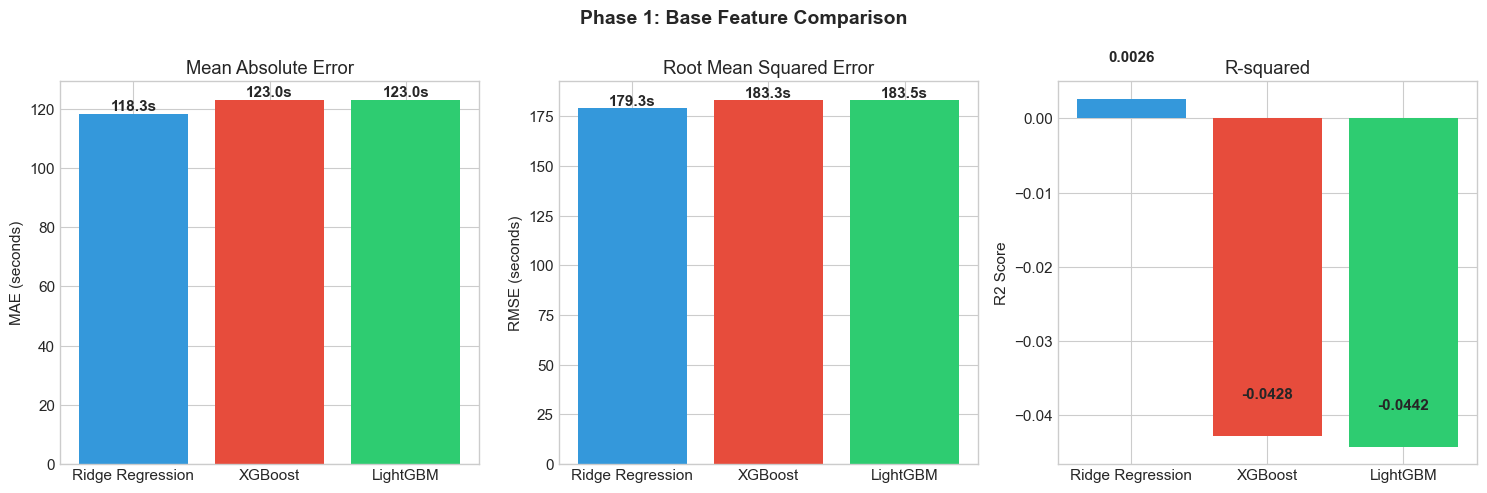

In [132]:
print("=" * 60)
print("4.4 Phase 1 Results")
print("=" * 60)

# Results table
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df['MAE (min)'] = results_df['MAE'] / 60
print()
display(results_df.round(2))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = list(results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71']

# MAE
mae_vals = [results[m]['MAE'] for m in models]
axes[0].bar(models, mae_vals, color=colors)
axes[0].set_ylabel('MAE (seconds)')
axes[0].set_title('Mean Absolute Error')
for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')

# RMSE
rmse_vals = [results[m]['RMSE'] for m in models]
axes[1].bar(models, rmse_vals, color=colors)
axes[1].set_ylabel('RMSE (seconds)')
axes[1].set_title('Root Mean Squared Error')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')

# R2
r2_vals = [results[m]['R2'] for m in models]
axes[2].bar(models, r2_vals, color=colors)
axes[2].set_ylabel('R2 Score')
axes[2].set_title('R-squared')
for i, v in enumerate(r2_vals):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Phase 1: Base Feature Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_phase1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Enhanced Feature Engineering

Add cyclical time encodings and historical aggregate features (computed from training data only to prevent leakage).

In [133]:
print("=" * 60)
print("6. Enhanced Feature Engineering")
print("=" * 60)

# Work with the full dataset (already sorted by time)
bus_enhanced = bus_df.copy()

# 1. Cyclical time encoding
bus_enhanced['hour_sin'] = np.sin(2 * np.pi * bus_enhanced['hour'] / 24)
bus_enhanced['hour_cos'] = np.cos(2 * np.pi * bus_enhanced['hour'] / 24)
bus_enhanced['dow_sin'] = np.sin(2 * np.pi * bus_enhanced['day_of_week'] / 7)
bus_enhanced['dow_cos'] = np.cos(2 * np.pi * bus_enhanced['day_of_week'] / 7)

# 2. Historical aggregates (from TRAINING set only to avoid leakage)
train_subset = bus_enhanced.iloc[:train_end]
global_train_mean = train_subset['delay_seconds'].mean()

# Route-hour mean delay
route_hour_mean = train_subset.groupby(['route_short_name', 'hour'])['delay_seconds'].mean()
bus_enhanced['route_hour_mean_delay'] = (
    bus_enhanced.set_index(['route_short_name', 'hour']).index
    .map(route_hour_mean)
)
bus_enhanced['route_hour_mean_delay'] = bus_enhanced['route_hour_mean_delay'].fillna(global_train_mean)

# Stop mean delay
stop_mean = train_subset.groupby('stop_id')['delay_seconds'].mean()
bus_enhanced['stop_mean_delay'] = bus_enhanced['stop_id'].map(stop_mean)
bus_enhanced['stop_mean_delay'] = bus_enhanced['stop_mean_delay'].fillna(global_train_mean)

# Route-direction mean delay
route_dir_mean = train_subset.groupby(['route_short_name', 'direction_id'])['delay_seconds'].mean()
bus_enhanced['route_dir_mean_delay'] = (
    bus_enhanced.set_index(['route_short_name', 'direction_id']).index
    .map(route_dir_mean)
)
bus_enhanced['route_dir_mean_delay'] = bus_enhanced['route_dir_mean_delay'].fillna(global_train_mean)

# Enhanced feature list
enhanced_feature_cols = feature_cols + [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'route_hour_mean_delay', 'stop_mean_delay', 'route_dir_mean_delay',
]

# Split enhanced data
X_train_e = bus_enhanced[enhanced_feature_cols].iloc[:train_end]
X_val_e = bus_enhanced[enhanced_feature_cols].iloc[train_end:val_end]
X_test_e = bus_enhanced[enhanced_feature_cols].iloc[val_end:]
# y_train, y_val, y_test unchanged

print(f"\nNew features added: {len(enhanced_feature_cols) - len(feature_cols)}")
print(f"   - hour_sin, hour_cos (cyclical hour)")
print(f"   - dow_sin, dow_cos (cyclical day of week)")
print(f"   - route_hour_mean_delay (historical avg by route+hour)")
print(f"   - stop_mean_delay (historical avg by stop)")
print(f"   - route_dir_mean_delay (historical avg by route+direction)")
print(f"\nTotal features: {len(feature_cols)} -> {len(enhanced_feature_cols)}")
print(f"\nLeakage check: all aggregates computed from training set only ({train_end:,} rows)")

6. Enhanced Feature Engineering

New features added: 7
   - hour_sin, hour_cos (cyclical hour)
   - dow_sin, dow_cos (cyclical day of week)
   - route_hour_mean_delay (historical avg by route+hour)
   - stop_mean_delay (historical avg by stop)
   - route_dir_mean_delay (historical avg by route+direction)

Total features: 16 -> 23

Leakage check: all aggregates computed from training set only (340,632 rows)


In [134]:
print("=" * 60)
print("5.1 Retrain All Models with Enhanced Features")
print("=" * 60)

results_v2 = {}

# --- Ridge Regression (Enhanced) ---
print("\n--- Ridge Regression (Enhanced) ---")
route_train_e = ohe.transform(X_train_e[['route_short_name']])
route_val_e = ohe.transform(X_val_e[['route_short_name']])
route_test_e = ohe.transform(X_test_e[['route_short_name']])

numeric_cols_e = [c for c in enhanced_feature_cols if c != 'route_short_name']
X_train_lr_e = np.hstack([X_train_e[numeric_cols_e].values, route_train_e])
X_val_lr_e = np.hstack([X_val_e[numeric_cols_e].values, route_val_e])
X_test_lr_e = np.hstack([X_test_e[numeric_cols_e].values, route_test_e])

ridge_v2 = Ridge(alpha=1.0)
ridge_v2.fit(X_train_lr_e, y_train)
y_pred_lr_v2 = ridge_v2.predict(X_test_lr_e)

mae_lr_v2 = mean_absolute_error(y_test, y_pred_lr_v2)
rmse_lr_v2 = np.sqrt(mean_squared_error(y_test, y_pred_lr_v2))
r2_lr_v2 = r2_score(y_test, y_pred_lr_v2)
results_v2['Ridge Regression'] = {'MAE': mae_lr_v2, 'RMSE': rmse_lr_v2, 'R2': r2_lr_v2}
print(f"   MAE: {mae_lr_v2:.2f}s | RMSE: {rmse_lr_v2:.2f}s | R2: {r2_lr_v2:.4f}")

# --- XGBoost (Enhanced) ---
print("\n--- XGBoost (Enhanced) ---")
X_train_xgb_e = X_train_e.copy()
X_val_xgb_e = X_val_e.copy()
X_test_xgb_e = X_test_e.copy()
X_train_xgb_e['route_short_name'] = X_train_xgb_e['route_short_name'].astype('category')
X_val_xgb_e['route_short_name'] = X_val_xgb_e['route_short_name'].astype('category')
X_test_xgb_e['route_short_name'] = X_test_xgb_e['route_short_name'].astype('category')

xgb_model_v2 = xgb.XGBRegressor(
    max_depth=6, learning_rate=0.05, n_estimators=1000,
    subsample=0.8, colsample_bytree=0.8,
    enable_categorical=True, tree_method='hist',
    random_state=42, early_stopping_rounds=50,
    eval_metric='mae', verbosity=0,
)
xgb_model_v2.fit(X_train_xgb_e, y_train, eval_set=[(X_val_xgb_e, y_val)], verbose=100)
y_pred_xgb_v2 = xgb_model_v2.predict(X_test_xgb_e)

mae_xgb_v2 = mean_absolute_error(y_test, y_pred_xgb_v2)
rmse_xgb_v2 = np.sqrt(mean_squared_error(y_test, y_pred_xgb_v2))
r2_xgb_v2 = r2_score(y_test, y_pred_xgb_v2)
results_v2['XGBoost'] = {'MAE': mae_xgb_v2, 'RMSE': rmse_xgb_v2, 'R2': r2_xgb_v2}
print(f"   MAE: {mae_xgb_v2:.2f}s | RMSE: {rmse_xgb_v2:.2f}s | R2: {r2_xgb_v2:.4f}")

# --- LightGBM (Enhanced) ---
print("\n--- LightGBM (Enhanced) ---")
X_train_lgb_e = X_train_e.copy()
X_val_lgb_e = X_val_e.copy()
X_test_lgb_e = X_test_e.copy()
X_train_lgb_e['route_short_name'] = X_train_lgb_e['route_short_name'].astype('category')
X_val_lgb_e['route_short_name'] = X_val_lgb_e['route_short_name'].astype('category')
X_test_lgb_e['route_short_name'] = X_test_lgb_e['route_short_name'].astype('category')

lgb_model_v2 = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=63, max_depth=-1,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model_v2.fit(
    X_train_lgb_e, y_train,
    eval_set=[(X_val_lgb_e, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)
y_pred_lgb_v2 = lgb_model_v2.predict(X_test_lgb_e)

mae_lgb_v2 = mean_absolute_error(y_test, y_pred_lgb_v2)
rmse_lgb_v2 = np.sqrt(mean_squared_error(y_test, y_pred_lgb_v2))
r2_lgb_v2 = r2_score(y_test, y_pred_lgb_v2)
results_v2['LightGBM'] = {'MAE': mae_lgb_v2, 'RMSE': rmse_lgb_v2, 'R2': r2_lgb_v2}
print(f"   MAE: {mae_lgb_v2:.2f}s | RMSE: {rmse_lgb_v2:.2f}s | R2: {r2_lgb_v2:.4f}")

# Feature importance (gain-based)
importance_lgb_v2 = pd.Series(
    lgb_model_v2.booster_.feature_importance(importance_type='gain'),
    index=X_train_lgb_e.columns,
).sort_values(ascending=False)
print("\n   Feature Importance (gain):")
print(importance_lgb_v2.round(2).to_string())


5.1 Retrain All Models with Enhanced Features

--- Ridge Regression (Enhanced) ---
   MAE: 108.26s | RMSE: 169.32s | R2: 0.1106

--- XGBoost (Enhanced) ---
[0]	validation_0-mae:142.05657
[51]	validation_0-mae:166.93118
   MAE: 120.99s | RMSE: 181.26s | R2: -0.0192

--- LightGBM (Enhanced) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 142.113	valid_0's l2: 52970.7
   MAE: 122.38s | RMSE: 182.69s | R2: -0.0354

   Feature Importance (gain):
route_hour_mean_delay        1.244750e+09
stop_mean_delay              9.859669e+08
precipitation_mm             5.330010e+08
humidity_percent             4.911574e+08
temperature_c                4.100994e+08
wind_speed_kmh               3.936982e+08
route_dir_mean_delay         3.118591e+08
dow_cos                      3.000910e+08
route_short_name             1.550459e+08
dow_sin                      1.415416e+08
stop_lat                     9.005170e+07
is_weekend             

6. Final Comparison: Phase 1 vs Phase 2

Best Model: Ridge Regression (Enhanced) (MAE: 108.26s)



,MAE,RMSE,R2,MAE (min)
Model,,,,
Ridge Regression (Base),118.25,179.31,0.00,1.97
Ridge Regression (Enhanced),108.26,169.32,0.11,1.80
XGBoost (Base),123.04,183.34,-0.04,2.05
XGBoost (Enhanced),120.99,181.26,-0.02,2.02
LightGBM (Base),122.99,183.47,-0.04,2.05
LightGBM (Enhanced),122.38,182.69,-0.04,2.04


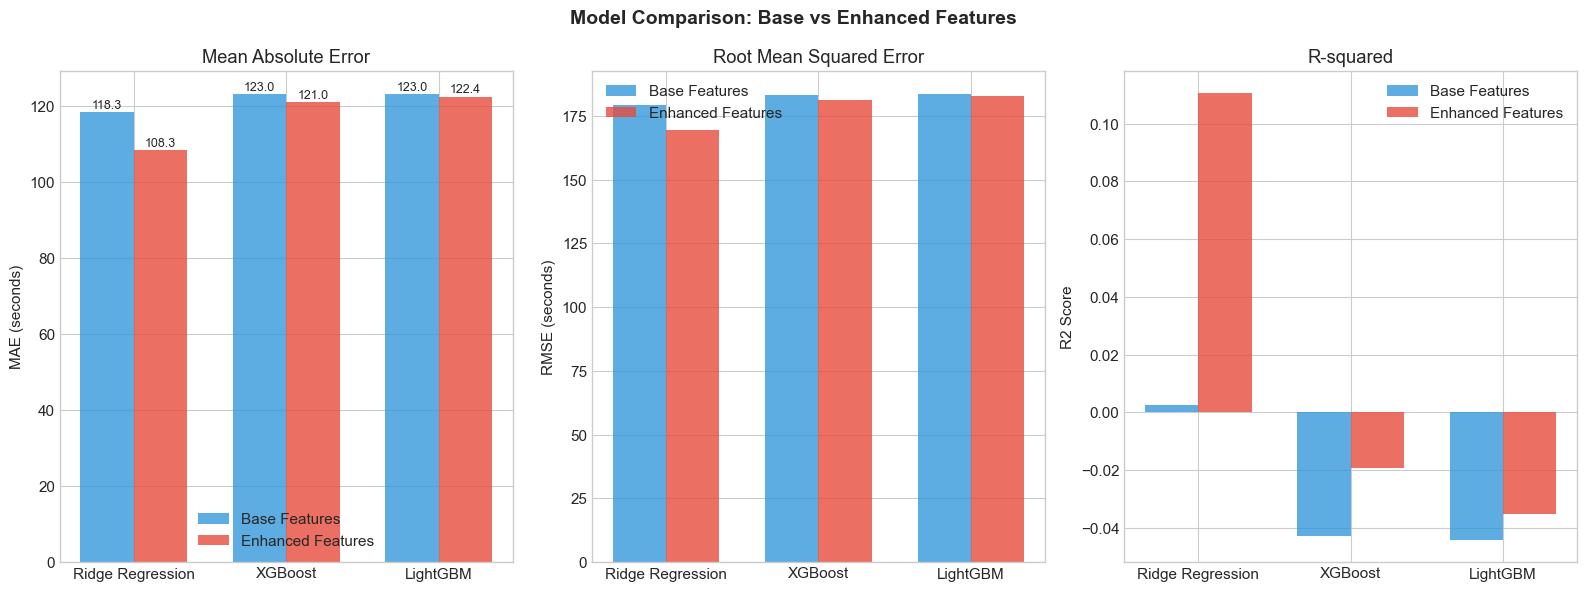

In [135]:
print("=" * 60)
print("6. Final Comparison: Phase 1 vs Phase 2")
print("=" * 60)

# Combined results table
all_results = {}
for model in results:
    all_results[f'{model} (Base)'] = results[model]
    all_results[f'{model} (Enhanced)'] = results_v2[model]

all_results_df = pd.DataFrame(all_results).T
all_results_df.index.name = 'Model'
all_results_df['MAE (min)'] = all_results_df['MAE'] / 60

# Highlight best
best_model = all_results_df['MAE'].idxmin()
print(f"\nBest Model: {best_model} (MAE: {all_results_df.loc[best_model, 'MAE']:.2f}s)")
print()
display(all_results_df.round(2))

# Side-by-side bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

models = list(results.keys())
x = np.arange(len(models))
width = 0.35

# MAE
mae_base = [results[m]['MAE'] for m in models]
mae_enh = [results_v2[m]['MAE'] for m in models]
axes[0].bar(x - width/2, mae_base, width, label='Base Features', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, mae_enh, width, label='Enhanced Features', color='#e74c3c', alpha=0.8)
axes[0].set_ylabel('MAE (seconds)')
axes[0].set_title('Mean Absolute Error')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
for i in range(len(models)):
    axes[0].text(i - width/2, mae_base[i] + 1, f'{mae_base[i]:.1f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, mae_enh[i] + 1, f'{mae_enh[i]:.1f}', ha='center', fontsize=9)

# RMSE
rmse_base = [results[m]['RMSE'] for m in models]
rmse_enh = [results_v2[m]['RMSE'] for m in models]
axes[1].bar(x - width/2, rmse_base, width, label='Base Features', color='#3498db', alpha=0.8)
axes[1].bar(x + width/2, rmse_enh, width, label='Enhanced Features', color='#e74c3c', alpha=0.8)
axes[1].set_ylabel('RMSE (seconds)')
axes[1].set_title('Root Mean Squared Error')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()

# R2
r2_base = [results[m]['R2'] for m in models]
r2_enh = [results_v2[m]['R2'] for m in models]
axes[2].bar(x - width/2, r2_base, width, label='Base Features', color='#3498db', alpha=0.8)
axes[2].bar(x + width/2, r2_enh, width, label='Enhanced Features', color='#e74c3c', alpha=0.8)
axes[2].set_ylabel('R2 Score')
axes[2].set_title('R-squared')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].legend()

plt.suptitle('Model Comparison: Base vs Enhanced Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [136]:
import joblib

# Identify best model
best_name = all_results_df['MAE'].idxmin()
print(f"Best model: {best_name}")
print(f"   MAE:  {all_results_df.loc[best_name, 'MAE']:.2f} seconds ({all_results_df.loc[best_name, 'MAE']/60:.2f} minutes)")
print(f"   RMSE: {all_results_df.loc[best_name, 'RMSE']:.2f} seconds")
print(f"   R2:   {all_results_df.loc[best_name, 'R2']:.4f}")

# Save the best model
if 'XGBoost' in best_name:
    model_to_save = xgb_model_v2 if 'Enhanced' in best_name else xgb_model
    model_to_save.save_model('delay_model_best.json')
    print(f"\nModel saved to delay_model_best.json (XGBoost)")
elif 'LightGBM' in best_name:
    model_to_save = lgb_model_v2 if 'Enhanced' in best_name else lgb_model
    joblib.dump(model_to_save, 'delay_model_best_lgb.joblib')
    print(f"\nModel saved to delay_model_best_lgb.joblib (LightGBM)")
elif 'Ridge' in best_name:
    model_to_save = ridge_v2 if 'Enhanced' in best_name else ridge
    joblib.dump(model_to_save, 'delay_model_best.joblib')
    print(f"\nModel saved to delay_model_best.joblib (Ridge)")

Best model: Ridge Regression (Enhanced)
   MAE:  108.26 seconds (1.80 minutes)
   RMSE: 169.32 seconds
   R2:   0.1106

Model saved to delay_model_best.joblib (Ridge)


---

## 7. Enhance 2: Re-defined Weather & Road Features

The Enhanced features shaved ~10s off Ridge's MAE but barely moved XGBoost / LightGBM.
Two likely reasons are that the **weather** and **road-condition** features are too crude:

- Weather is joined at a **10-minute bucket** with mean-only aggregation, so short bursts
  of rain or wind (the things that actually slow buses down) get smoothed out.
- Road features use a hard **5 km radius** and — more importantly — **ignore time**:
  every bus visit to a stop gets the same `active_incidents` / `nearest_event_distance_km`
  regardless of when the event was created, so an incident created in February is
  already "active" for a bus in January.

Enhance 2 rebuilds these two feature groups:

1. **Weather v2** — 5-minute bucket + rolling-1h stats (`precip_1h_sum/max`, `wind_1h_max`,
   `temp_delta_1h`) + binary flags (`is_raining`, `is_heavy_rain`).
2. **Road v2** — time-aware via `created_at`, multi-radius counts (1 / 3 / 10 km),
   severity-weighted distance decay, and nearest *active* event distance.


In [137]:
# ============================================================
# 7. Enhance 2: Redefined Weather & Road Features
# ============================================================
print("=" * 60)
print("7. Enhance 2: Redefined Weather & Road Features")
print("=" * 60)

# Start from the Enhanced frame so we keep cyclical time + historical aggregates,
# and overwrite the time-invariant road features with time-aware ones below.
bus_v3 = bus_enhanced.copy()
assert bus_v3['recorded_at'].is_monotonic_increasing, "bus_v3 must be sorted by recorded_at"

# ---- Weather v2: finer 5-min bucket + rolling-1h stats + binary flags ----
weather_df_v2 = weather_df.copy()
weather_df_v2['weather_time_v2'] = weather_df_v2['recorded_at'].dt.floor('5min')

weather_v2 = (
    weather_df_v2.groupby('weather_time_v2')
    .agg(temperature_c=('temperature_c', 'mean'),
         humidity_percent=('humidity_percent', 'mean'),
         wind_speed_kmh=('wind_speed_kmh', 'mean'),
         precipitation_mm=('precipitation_mm', 'mean'))
    .reset_index()
    .sort_values('weather_time_v2')
    .reset_index(drop=True)
)

# Rolling 1-hour stats (12 five-minute windows = 60 minutes)
W = 12
weather_v2['precip_1h_sum'] = weather_v2['precipitation_mm'].rolling(W, min_periods=1).sum()
weather_v2['precip_1h_max'] = weather_v2['precipitation_mm'].rolling(W, min_periods=1).max()
weather_v2['wind_1h_max']   = weather_v2['wind_speed_kmh'].rolling(W, min_periods=1).max()
weather_v2['temp_delta_1h'] = weather_v2['temperature_c'] - weather_v2['temperature_c'].shift(W)
weather_v2['is_raining']    = (weather_v2['precipitation_mm'] > 0.1).astype(int)
weather_v2['is_heavy_rain'] = (weather_v2['precipitation_mm'] > 2.0).astype(int)

weather_v2_cols = ['precip_1h_sum', 'precip_1h_max', 'wind_1h_max',
                   'temp_delta_1h', 'is_raining', 'is_heavy_rain']

bus_v3['weather_time_v2'] = bus_v3['recorded_at'].dt.floor('5min')
bus_v3 = bus_v3.merge(
    weather_v2[['weather_time_v2'] + weather_v2_cols],
    on='weather_time_v2', how='left',
)
bus_v3[weather_v2_cols] = bus_v3[weather_v2_cols].ffill().bfill().fillna(0)

print(f"Weather v2: 5-min bucket, weather_agg rows = {len(weather_v2):,}, "
      f"new columns = {len(weather_v2_cols)}")
print(f"   % of bus rows raining:      {bus_v3['is_raining'].mean() * 100:.1f}%")
print(f"   % of bus rows heavy rain:   {bus_v3['is_heavy_rain'].mean() * 100:.1f}%")


7. Enhance 2: Redefined Weather & Road Features
Weather v2: 5-min bucket, weather_agg rows = 4,828, new columns = 6
   % of bus rows raining:      22.9%
   % of bus rows heavy rain:   1.9%


In [138]:
# ---- Road v2: time-aware, multi-radius, severity-weighted decay ----
# Plan:
#   1. Precompute distance between every unique stop and every road event.
#   2. Keep (stop, event) pairs within 10 km.
#   3. Per stop, sort by event `created_at` and take cumulative counts at
#      1 / 3 / 10 km + cumulative severity-weighted decay + running nearest distance.
#   4. Merge-asof into bus_v3 on recorded_at (backward) per stop — so each bus row
#      only sees events created *before* it.

road_v2 = road_df.copy()
road_v2['created_at'] = pd.to_datetime(road_v2['created_at'], format='ISO8601', utc=True)
road_v2['severity_w'] = road_v2['severity'].map({'MAJOR': 3.0, 'MINOR': 1.0}).fillna(1.0)
road_v2 = road_v2.reset_index(drop=True)

stops_unique = (
    bus_v3[['stop_id', 'stop_lat', 'stop_lon']]
    .drop_duplicates()
    .reset_index(drop=True)
)


def haversine_matrix(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lon1 = np.radians(np.asarray(lon1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lon2 = np.radians(np.asarray(lon2, dtype=float))[None, :]
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


dist_mat = haversine_matrix(
    stops_unique['stop_lat'].values, stops_unique['stop_lon'].values,
    road_v2['lat'].values, road_v2['lon'].values,
)  # shape (n_stops, n_events)

RADIUS_MAX_KM = 10.0
# Vectorized pair extraction: rows where distance < RADIUS_MAX_KM
s_idx, e_idx = np.where(dist_mat < RADIUS_MAX_KM)
pairs_df = pd.DataFrame({
    'stop_id':    stops_unique.loc[s_idx, 'stop_id'].values,
    'distance_km': dist_mat[s_idx, e_idx],
    'created_at':  road_v2.loc[e_idx, 'created_at'].values,
    'severity_w':  road_v2.loc[e_idx, 'severity_w'].values,
})
# Align stop_id dtype with bus_v3 (it is Int64 nullable), and re-attach UTC
# timezone on created_at (numpy .values dropped the tz during construction above)
pairs_df['stop_id'] = pairs_df['stop_id'].astype(bus_v3['stop_id'].dtype)
pairs_df['created_at'] = pd.to_datetime(pairs_df['created_at'], utc=True)
print(f"Stops: {len(stops_unique):,} | Events: {len(road_v2):,} | "
      f"pairs within {RADIUS_MAX_KM:.0f}km: {len(pairs_df):,}")

# Cumulative per-stop features over event-creation time
pairs_df = pairs_df.sort_values(['stop_id', 'created_at']).reset_index(drop=True)
pairs_df['in_1km']  = (pairs_df['distance_km'] < 1.0).astype(float)
pairs_df['in_3km']  = (pairs_df['distance_km'] < 3.0).astype(float)
pairs_df['in_10km'] = (pairs_df['distance_km'] < 10.0).astype(float)
pairs_df['decay_score'] = pairs_df['severity_w'] * np.exp(-pairs_df['distance_km'] / 3.0)

grp = pairs_df.groupby('stop_id', sort=False)
pairs_df['cum_events_1km']  = grp['in_1km'].cumsum()
pairs_df['cum_events_3km']  = grp['in_3km'].cumsum()
pairs_df['cum_events_10km'] = grp['in_10km'].cumsum()
pairs_df['cum_decay_score'] = grp['decay_score'].cumsum()
pairs_df['cum_min_dist_km'] = grp['distance_km'].cummin()

road_v2_feats = (
    pairs_df[['stop_id', 'created_at',
              'cum_events_1km', 'cum_events_3km', 'cum_events_10km',
              'cum_decay_score', 'cum_min_dist_km']]
    .sort_values('created_at')
    .reset_index(drop=True)
)

# merge_asof: for each bus row, pick latest cumulative state with created_at <= recorded_at
bus_v3 = bus_v3.sort_values('recorded_at').reset_index(drop=True)
new_road_cols = ['cum_events_1km', 'cum_events_3km', 'cum_events_10km',
                 'cum_decay_score', 'cum_min_dist_km']
bus_v3 = pd.merge_asof(
    bus_v3,
    road_v2_feats,
    left_on='recorded_at', right_on='created_at',
    by='stop_id', direction='backward',
)
# Rows before any event is created -> fill with zeros / large distance
fill_values = {'cum_events_1km': 0.0, 'cum_events_3km': 0.0, 'cum_events_10km': 0.0,
               'cum_decay_score': 0.0, 'cum_min_dist_km': 50.0}
bus_v3[new_road_cols] = bus_v3[new_road_cols].fillna(fill_values)
bus_v3 = bus_v3.drop(columns=['created_at'])

# Sanity check: row count preserved and still aligned with y_train/y_val/y_test
assert len(bus_v3) == len(bus_enhanced), (
    f"Row count changed: {len(bus_v3)} vs {len(bus_enhanced)}")

print("Road v2 merged. Preview of new columns:")
print(bus_v3[new_road_cols].describe().round(2))


Stops: 979 | Events: 1,620 | pairs within 10km: 196,653
Road v2 merged. Preview of new columns:
       cum_events_1km  cum_events_3km  cum_events_10km  cum_decay_score  \
count       425790.00       425790.00        425790.00        425790.00   
mean             1.15           11.64           152.16            44.84   
std              3.06           12.91            83.02            28.20   
min              0.00            0.00             2.00             0.17   
25%              0.00            0.00            88.00            22.89   
50%              0.00            4.00           135.00            41.68   
75%              0.00           23.00           211.00            61.58   
max             17.00           57.00           381.00           139.03   

       cum_min_dist_km  
count        425790.00  
mean              2.42  
std               1.47  
min               0.04  
25%               1.16  
50%               2.19  
75%               3.52  
max               9.36  


In [139]:
# ---- Build Enhance 2 feature list and temporal splits ----
# Drop the broken time-invariant road features; keep everything else from Enhanced.
feature_cols_v3 = [c for c in enhanced_feature_cols
                   if c not in ['active_incidents', 'active_construction',
                                'nearest_event_distance_km']]
feature_cols_v3 += weather_v2_cols + new_road_cols

print(f"Feature count: Base={len(feature_cols)}  "
      f"Enhanced={len(enhanced_feature_cols)}  Enhance 2={len(feature_cols_v3)}")
print(f"Dropped (time-invariant): active_incidents, active_construction, nearest_event_distance_km")
print(f"Added weather: {weather_v2_cols}")
print(f"Added road:    {new_road_cols}")

# Same temporal split boundaries as before (train_end / val_end from cell 12)
X_train_v3 = bus_v3[feature_cols_v3].iloc[:train_end]
X_val_v3   = bus_v3[feature_cols_v3].iloc[train_end:val_end]
X_test_v3  = bus_v3[feature_cols_v3].iloc[val_end:]
# y_train / y_val / y_test unchanged

print(f"\nShapes: X_train_v3={X_train_v3.shape}  X_val_v3={X_val_v3.shape}  X_test_v3={X_test_v3.shape}")


Feature count: Base=16  Enhanced=23  Enhance 2=31
Dropped (time-invariant): active_incidents, active_construction, nearest_event_distance_km
Added weather: ['precip_1h_sum', 'precip_1h_max', 'wind_1h_max', 'temp_delta_1h', 'is_raining', 'is_heavy_rain']
Added road:    ['cum_events_1km', 'cum_events_3km', 'cum_events_10km', 'cum_decay_score', 'cum_min_dist_km']

Shapes: X_train_v3=(340632, 31)  X_val_v3=(42579, 31)  X_test_v3=(42579, 31)


In [140]:
print("=" * 60)
print("7.1 Retrain All Models with Enhance 2 Features")
print("=" * 60)

results_v3 = {}

# --- Ridge Regression (Enhance 2) ---
print("\n--- Ridge Regression (Enhance 2) ---")
route_train_v3 = ohe.transform(X_train_v3[['route_short_name']])
route_val_v3   = ohe.transform(X_val_v3[['route_short_name']])
route_test_v3  = ohe.transform(X_test_v3[['route_short_name']])

numeric_cols_v3 = [c for c in feature_cols_v3 if c != 'route_short_name']
X_train_lr_v3 = np.hstack([X_train_v3[numeric_cols_v3].values, route_train_v3])
X_val_lr_v3   = np.hstack([X_val_v3[numeric_cols_v3].values, route_val_v3])
X_test_lr_v3  = np.hstack([X_test_v3[numeric_cols_v3].values, route_test_v3])

ridge_v3 = Ridge(alpha=1.0)
ridge_v3.fit(X_train_lr_v3, y_train)
y_pred_lr_v3 = ridge_v3.predict(X_test_lr_v3)

mae_lr_v3  = mean_absolute_error(y_test, y_pred_lr_v3)
rmse_lr_v3 = np.sqrt(mean_squared_error(y_test, y_pred_lr_v3))
r2_lr_v3   = r2_score(y_test, y_pred_lr_v3)
results_v3['Ridge Regression'] = {'MAE': mae_lr_v3, 'RMSE': rmse_lr_v3, 'R2': r2_lr_v3}
print(f"   MAE: {mae_lr_v3:.2f}s | RMSE: {rmse_lr_v3:.2f}s | R2: {r2_lr_v3:.4f}")

# --- XGBoost (Enhance 2) ---
print("\n--- XGBoost (Enhance 2) ---")
X_train_xgb_v3 = X_train_v3.copy()
X_val_xgb_v3   = X_val_v3.copy()
X_test_xgb_v3  = X_test_v3.copy()
for df in (X_train_xgb_v3, X_val_xgb_v3, X_test_xgb_v3):
    df['route_short_name'] = df['route_short_name'].astype('category')

xgb_model_v3 = xgb.XGBRegressor(
    max_depth=6, learning_rate=0.05, n_estimators=1000,
    subsample=0.8, colsample_bytree=0.8,
    enable_categorical=True, tree_method='hist',
    random_state=42, early_stopping_rounds=50,
    eval_metric='mae', verbosity=0,
)
xgb_model_v3.fit(X_train_xgb_v3, y_train, eval_set=[(X_val_xgb_v3, y_val)], verbose=100)
y_pred_xgb_v3 = xgb_model_v3.predict(X_test_xgb_v3)

mae_xgb_v3  = mean_absolute_error(y_test, y_pred_xgb_v3)
rmse_xgb_v3 = np.sqrt(mean_squared_error(y_test, y_pred_xgb_v3))
r2_xgb_v3   = r2_score(y_test, y_pred_xgb_v3)
results_v3['XGBoost'] = {'MAE': mae_xgb_v3, 'RMSE': rmse_xgb_v3, 'R2': r2_xgb_v3}
print(f"   MAE: {mae_xgb_v3:.2f}s | RMSE: {rmse_xgb_v3:.2f}s | R2: {r2_xgb_v3:.4f}")

# --- LightGBM (Enhance 2) ---
print("\n--- LightGBM (Enhance 2) ---")
X_train_lgb_v3 = X_train_v3.copy()
X_val_lgb_v3   = X_val_v3.copy()
X_test_lgb_v3  = X_test_v3.copy()
for df in (X_train_lgb_v3, X_val_lgb_v3, X_test_lgb_v3):
    df['route_short_name'] = df['route_short_name'].astype('category')

lgb_model_v3 = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=63, max_depth=-1,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model_v3.fit(
    X_train_lgb_v3, y_train,
    eval_set=[(X_val_lgb_v3, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)
y_pred_lgb_v3 = lgb_model_v3.predict(X_test_lgb_v3)

mae_lgb_v3  = mean_absolute_error(y_test, y_pred_lgb_v3)
rmse_lgb_v3 = np.sqrt(mean_squared_error(y_test, y_pred_lgb_v3))
r2_lgb_v3   = r2_score(y_test, y_pred_lgb_v3)
results_v3['LightGBM'] = {'MAE': mae_lgb_v3, 'RMSE': rmse_lgb_v3, 'R2': r2_lgb_v3}
print(f"   MAE: {mae_lgb_v3:.2f}s | RMSE: {rmse_lgb_v3:.2f}s | R2: {r2_lgb_v3:.4f}")

# Feature importance (gain-based) for LightGBM to see if the new features matter
importance_lgb_v3 = pd.Series(
    lgb_model_v3.booster_.feature_importance(importance_type='gain'),
    index=X_train_lgb_v3.columns,
).sort_values(ascending=False)
print("\n   Feature Importance (gain):")
print(importance_lgb_v3.round(2).to_string())


7.1 Retrain All Models with Enhance 2 Features

--- Ridge Regression (Enhance 2) ---
   MAE: 117.31s | RMSE: 184.08s | R2: -0.0512

--- XGBoost (Enhance 2) ---
[0]	validation_0-mae:142.52828
[52]	validation_0-mae:149.65864
   MAE: 121.19s | RMSE: 182.66s | R2: -0.0351

--- LightGBM (Enhance 2) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 142.241	valid_0's l2: 53314.9
   MAE: 123.07s | RMSE: 183.60s | R2: -0.0457

   Feature Importance (gain):
wind_1h_max              501955210.0
precip_1h_sum            371278508.0
hour                     297537230.0
hour_cos                 236587308.0
is_raining               230796992.0
stop_lat                 191327200.0
route_hour_mean_delay    183520100.0
dow_sin                  148219994.0
cum_events_10km          113510080.0
humidity_percent          92437300.0
temperature_c             71985190.0
stop_mean_delay           64256700.0
wind_speed_kmh            49011100.0

7.2 Three-way Comparison: Base vs Enhanced vs Enhance 2

Best Model: Ridge Regression (Enhanced) (MAE: 108.26s)


,MAE,RMSE,R2,MAE (min)
Model,,,,
Ridge Regression (Base),118.25,179.31,0.00,1.97
Ridge Regression (Enhanced),108.26,169.32,0.11,1.80
Ridge Regression (Enhance 2),117.31,184.08,-0.05,1.96
XGBoost (Base),123.04,183.34,-0.04,2.05
XGBoost (Enhanced),120.99,181.26,-0.02,2.02
XGBoost (Enhance 2),121.19,182.66,-0.04,2.02
LightGBM (Base),122.99,183.47,-0.04,2.05
LightGBM (Enhanced),122.38,182.69,-0.04,2.04
LightGBM (Enhance 2),123.07,183.60,-0.05,2.05


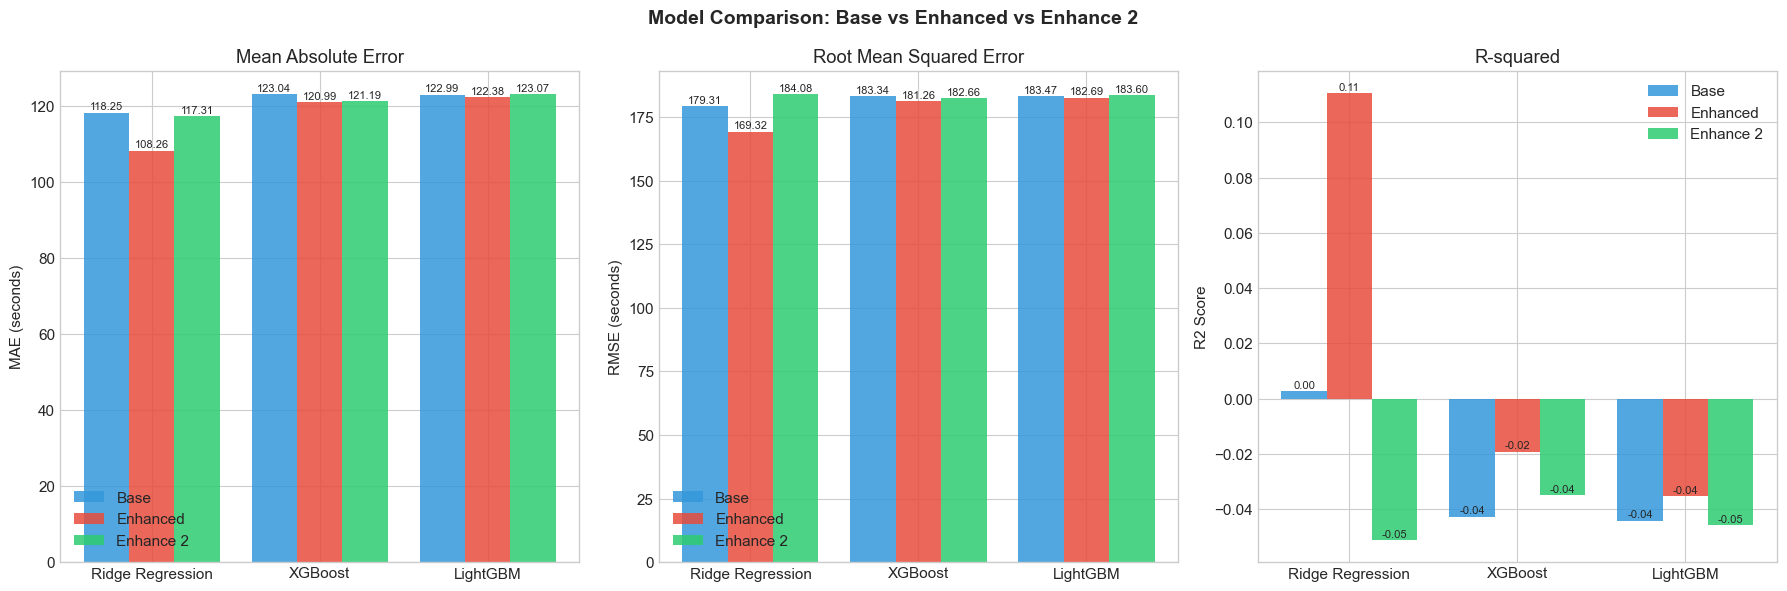


MAE delta (Enhance 2 - Enhanced), negative = improvement:
   Ridge Regression     +9.05s
   XGBoost              +0.20s
   LightGBM             +0.69s


In [141]:
print("=" * 60)
print("7.2 Three-way Comparison: Base vs Enhanced vs Enhance 2")
print("=" * 60)

all_results_v3 = {}
for m in results:
    all_results_v3[f'{m} (Base)']       = results[m]
    all_results_v3[f'{m} (Enhanced)']   = results_v2[m]
    all_results_v3[f'{m} (Enhance 2)']  = results_v3[m]

all_results_v3_df = pd.DataFrame(all_results_v3).T
all_results_v3_df.index.name = 'Model'
all_results_v3_df['MAE (min)'] = all_results_v3_df['MAE'] / 60

best_model_v3 = all_results_v3_df['MAE'].idxmin()
print(f"\nBest Model: {best_model_v3} (MAE: {all_results_v3_df.loc[best_model_v3, 'MAE']:.2f}s)")
display(all_results_v3_df.round(2))

# Three-way grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = list(results.keys())
x = np.arange(len(models))
width = 0.27


def triple_bar(ax, base_vals, enh_vals, enh2_vals, title, ylabel):
    b1 = ax.bar(x - width, base_vals, width, label='Base',       color='#3498db', alpha=0.85)
    b2 = ax.bar(x,         enh_vals,  width, label='Enhanced',   color='#e74c3c', alpha=0.85)
    b3 = ax.bar(x + width, enh2_vals, width, label='Enhance 2',  color='#2ecc71', alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    for rects in (b1, b2, b3):
        for r in rects:
            h = r.get_height()
            ax.annotate(f'{h:.2f}', xy=(r.get_x() + r.get_width() / 2, h),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', fontsize=8)


mae_b  = [results[m]['MAE']    for m in models]
mae_e  = [results_v2[m]['MAE'] for m in models]
mae_e2 = [results_v3[m]['MAE'] for m in models]
triple_bar(axes[0], mae_b, mae_e, mae_e2, 'Mean Absolute Error', 'MAE (seconds)')

rmse_b  = [results[m]['RMSE']    for m in models]
rmse_e  = [results_v2[m]['RMSE'] for m in models]
rmse_e2 = [results_v3[m]['RMSE'] for m in models]
triple_bar(axes[1], rmse_b, rmse_e, rmse_e2, 'Root Mean Squared Error', 'RMSE (seconds)')

r2_b  = [results[m]['R2']    for m in models]
r2_e  = [results_v2[m]['R2'] for m in models]
r2_e2 = [results_v3[m]['R2'] for m in models]
triple_bar(axes[2], r2_b, r2_e, r2_e2, 'R-squared', 'R2 Score')

plt.suptitle('Model Comparison: Base vs Enhanced vs Enhance 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_enhance2.png', dpi=150, bbox_inches='tight')
plt.show()

# Delta summary vs Enhanced
print("\nMAE delta (Enhance 2 - Enhanced), negative = improvement:")
for m in models:
    d = results_v3[m]['MAE'] - results_v2[m]['MAE']
    print(f"   {m:<20s} {d:+.2f}s")


---

## 8. Algorithm swap: nonlinear kernel SVM

Enhance 2 didn't pay off (see cell 27), so the bottleneck may be the model
family rather than the features. Try a **nonlinear kernel SVM** instead of
XGBoost / LightGBM, on the Enhanced feature set (which is still our best).

**Scale constraint:** we have ~1.7M training rows. True `SVR(kernel='rbf')`
is ~O(n² .. n³); sklearn's own docs recommend it for ≤ a few 10k samples.
So we use two complementary approaches:

1. **Nystroem(RBF) + LinearSVR** on the full training set — kernel
   approximation that projects features into a ~300-D RBF basis, then solves
   a linear SVR in that space. This is the standard "nonlinear SVM at scale".
2. **True `SVR(kernel='rbf')`** on a 20k stratified subsample — reference
   point to see what the exact kernel SVM looks like on a slice of the data.


8. Nonlinear kernel SVM on Enhanced features
Scaled design matrix: train=(340632, 35), test=(42579, 35)

--- (a) Nystroem(RBF) + LinearSVR (full train) ---
   MAE: 102.18s | RMSE: 171.32s | R2: 0.0894 | fit+predict: 4.0s

--- (b) True SVR(kernel='rbf') on 20,000 train subsample ---
   MAE: 105.48s | RMSE: 173.93s | R2: 0.0616 | fit+predict: 64.5s
   (n_support_vectors: 19,982)

All models on Enhanced features (sorted by MAE)


,MAE,RMSE,R2,MAE (min)
Model,,,,
Nystroem(RBF)+LinearSVR,102.18,171.32,0.09,1.70
SVR(RBF) 20k subset,105.48,173.93,0.06,1.76
Ridge Regression,108.26,169.32,0.11,1.80
XGBoost,120.99,181.26,-0.02,2.02
LightGBM,122.38,182.69,-0.04,2.04


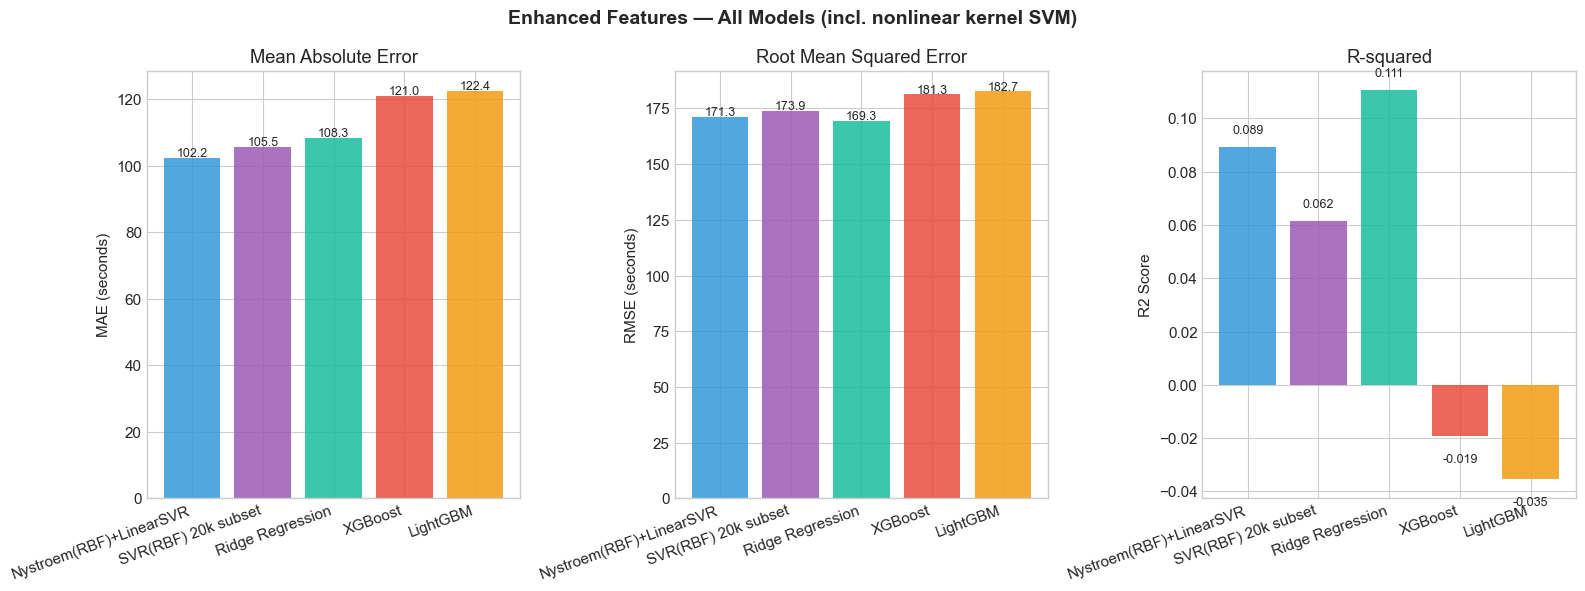

In [142]:
# ============================================================
# 8. Nonlinear kernel SVM (RBF) on Enhanced features
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import LinearSVR, SVR
from sklearn.pipeline import Pipeline
import time

print("=" * 60)
print("8. Nonlinear kernel SVM on Enhanced features")
print("=" * 60)

# Reuse the Enhanced Ridge design matrix (numeric features + one-hot route).
# SVM is distance-based so we need to scale first.
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train_lr_e)
X_val_svm   = scaler_svm.transform(X_val_lr_e)
X_test_svm  = scaler_svm.transform(X_test_lr_e)
print(f"Scaled design matrix: train={X_train_svm.shape}, test={X_test_svm.shape}")

results_svm = {}

# ---- (a) Nystroem(RBF) + LinearSVR — full-data kernel approximation ----
print("\n--- (a) Nystroem(RBF) + LinearSVR (full train) ---")
t0 = time.time()
ny_svr = Pipeline([
    ('nystroem', Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42)),
    ('svr', LinearSVR(C=1.0, epsilon=0.0, max_iter=2000, random_state=42)),
])
ny_svr.fit(X_train_svm, y_train)
y_pred_a = ny_svr.predict(X_test_svm)
mae_a  = mean_absolute_error(y_test, y_pred_a)
rmse_a = np.sqrt(mean_squared_error(y_test, y_pred_a))
r2_a   = r2_score(y_test, y_pred_a)
results_svm['Nystroem(RBF)+LinearSVR'] = {'MAE': mae_a, 'RMSE': rmse_a, 'R2': r2_a}
print(f"   MAE: {mae_a:.2f}s | RMSE: {rmse_a:.2f}s | R2: {r2_a:.4f} | fit+predict: {time.time()-t0:.1f}s")

# ---- (b) True SVR(rbf) on 20k subsample — reference exact kernel ----
SUBSAMPLE = 20_000
print(f"\n--- (b) True SVR(kernel='rbf') on {SUBSAMPLE:,} train subsample ---")
rng = np.random.RandomState(42)
sub_idx = rng.choice(len(y_train), size=min(SUBSAMPLE, len(y_train)), replace=False)
X_sub  = X_train_svm[sub_idx]
y_sub  = y_train.iloc[sub_idx].values if hasattr(y_train, 'iloc') else np.asarray(y_train)[sub_idx]

t0 = time.time()
svr_rbf = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale', cache_size=500)
svr_rbf.fit(X_sub, y_sub)
y_pred_b = svr_rbf.predict(X_test_svm)
mae_b  = mean_absolute_error(y_test, y_pred_b)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_b))
r2_b   = r2_score(y_test, y_pred_b)
results_svm['SVR(RBF) 20k subset'] = {'MAE': mae_b, 'RMSE': rmse_b, 'R2': r2_b}
print(f"   MAE: {mae_b:.2f}s | RMSE: {rmse_b:.2f}s | R2: {r2_b:.4f} | fit+predict: {time.time()-t0:.1f}s")
print(f"   (n_support_vectors: {svr_rbf.support_.shape[0]:,})")

# ---- Full comparison on Enhanced features ----
print("\n" + "=" * 60)
print("All models on Enhanced features (sorted by MAE)")
print("=" * 60)

comparison = {
    'Ridge Regression': results_v2['Ridge Regression'],
    'XGBoost':          results_v2['XGBoost'],
    'LightGBM':         results_v2['LightGBM'],
    **results_svm,
}
comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = 'Model'
comparison_df['MAE (min)'] = comparison_df['MAE'] / 60
comparison_df = comparison_df.sort_values('MAE')
display(comparison_df.round(2))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
labels = list(comparison_df.index)
x = np.arange(len(labels))
colors = ['#3498db', '#9b59b6', '#1abc9c', '#e74c3c', '#f39c12']
colors = colors[:len(labels)]

axes[0].bar(x, comparison_df['MAE'].values, color=colors, alpha=0.85)
axes[0].set_ylabel('MAE (seconds)')
axes[0].set_title('Mean Absolute Error')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=20, ha='right')
for i, v in enumerate(comparison_df['MAE'].values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(x, comparison_df['RMSE'].values, color=colors, alpha=0.85)
axes[1].set_ylabel('RMSE (seconds)')
axes[1].set_title('Root Mean Squared Error')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=20, ha='right')
for i, v in enumerate(comparison_df['RMSE'].values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

axes[2].bar(x, comparison_df['R2'].values, color=colors, alpha=0.85)
axes[2].set_ylabel('R2 Score')
axes[2].set_title('R-squared')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=20, ha='right')
for i, v in enumerate(comparison_df['R2'].values):
    axes[2].text(i, v + (0.005 if v >= 0 else -0.01), f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Enhanced Features — All Models (incl. nonlinear kernel SVM)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_svm.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.1 Isolate nonlinearity vs loss function (2×2 factorial)

The Nystroem+LinearSVR win (102.2 vs 108.3 MAE) is confounded: it changes
**both** the feature space (linear → RBF kernel) **and** the loss function
(L2 → ε-insensitive L1). To attribute the gain, fit the missing two corners
of the 2×2:

|                  | Linear features       | RBF kernel (Nystroem)        |
|------------------|-----------------------|------------------------------|
| **L2 loss**      | Ridge (already have)  | Nystroem + Ridge (new)       |
| **L1-ε loss**    | LinearSVR (new)       | Nystroem + LinearSVR (have)  |

Reading the table:
- If **Nystroem+Ridge ≈ Ridge** → nonlinearity doesn't help; the win is from the L1 loss.
- If **LinearSVR ≈ Nystroem+LinearSVR** → the kernel doesn't help; same story.
- If both the top-right and bottom-left move → both contribute.


8.1 Isolate nonlinearity vs loss function (2x2 factorial)

--- (c) LinearSVR, no kernel ---
   MAE: 102.32s | RMSE: 170.90s | R2: 0.0940 | (1.0s)

--- (d) Nystroem(RBF) + Ridge ---
   MAE: 115.49s | RMSE: 177.66s | R2: 0.0208 | (3.1s)

Factorial results (sorted by MAE)


,MAE,RMSE,R2
"Nystroem+LinSVR (L1, RBF)",102.177,171.325,0.089
"LinearSVR (L1, linear)",102.321,170.898,0.094
"Ridge (L2, linear)",108.256,169.321,0.111
"Nystroem+Ridge (L2, RBF)",115.486,177.661,0.021



MAE attribution (vs Ridge baseline, negative = improvement):
  Loss only   (Ridge          -> LinearSVR):      -5.93s
  Kernel only (Ridge          -> Nystroem+Ridge): +7.23s
  Both        (Ridge          -> Nystroem+LinSVR): -6.08s


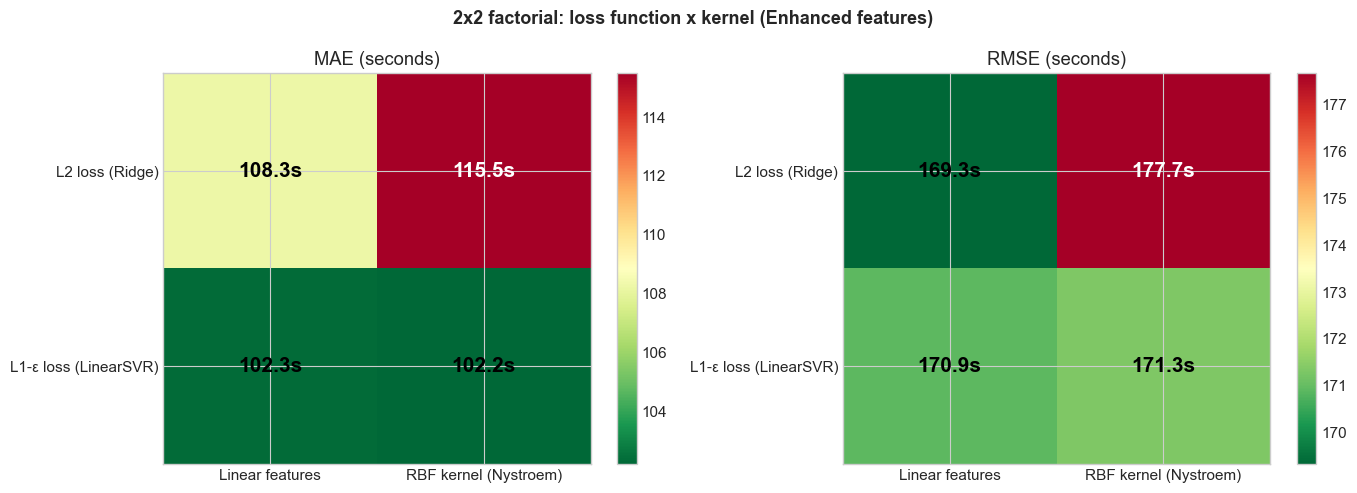

In [143]:
# ============================================================
# 8.1 Loss-function x kernel factorial on Enhanced features
# ============================================================
print("=" * 60)
print("8.1 Isolate nonlinearity vs loss function (2x2 factorial)")
print("=" * 60)

# Reuse scaled Enhanced design matrix from cell 29: X_train_svm / X_val_svm / X_test_svm
# Reuse Ridge (L2 linear) from results_v2 and Nystroem+LinearSVR (L1 RBF) from results_svm

# --- (c) LinearSVR, no kernel (L1-epsilon loss on linear features) ---
print("\n--- (c) LinearSVR, no kernel ---")
t0 = time.time()
lin_svr = LinearSVR(C=1.0, epsilon=0.0, max_iter=2000, random_state=42)
lin_svr.fit(X_train_svm, y_train)
y_pred_c = lin_svr.predict(X_test_svm)
mae_c  = mean_absolute_error(y_test, y_pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test, y_pred_c))
r2_c   = r2_score(y_test, y_pred_c)
print(f"   MAE: {mae_c:.2f}s | RMSE: {rmse_c:.2f}s | R2: {r2_c:.4f} | ({time.time()-t0:.1f}s)")

# --- (d) Nystroem(RBF) + Ridge (kernel ridge, L2 loss) ---
print("\n--- (d) Nystroem(RBF) + Ridge ---")
t0 = time.time()
ny_ridge = Pipeline([
    ('nystroem', Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42)),
    ('ridge', Ridge(alpha=1.0)),
])
ny_ridge.fit(X_train_svm, y_train)
y_pred_d = ny_ridge.predict(X_test_svm)
mae_d  = mean_absolute_error(y_test, y_pred_d)
rmse_d = np.sqrt(mean_squared_error(y_test, y_pred_d))
r2_d   = r2_score(y_test, y_pred_d)
print(f"   MAE: {mae_d:.2f}s | RMSE: {rmse_d:.2f}s | R2: {r2_d:.4f} | ({time.time()-t0:.1f}s)")

# --- Factorial table ---
ridge_row        = results_v2['Ridge Regression']
ny_linsvr_row    = results_svm['Nystroem(RBF)+LinearSVR']

factorial = pd.DataFrame({
    'MAE':  [ridge_row['MAE'],  mae_c, mae_d, ny_linsvr_row['MAE']],
    'RMSE': [ridge_row['RMSE'], rmse_c, rmse_d, ny_linsvr_row['RMSE']],
    'R2':   [ridge_row['R2'],   r2_c, r2_d, ny_linsvr_row['R2']],
}, index=[
    'Ridge           (L2, linear)',
    'LinearSVR       (L1, linear)',
    'Nystroem+Ridge  (L2, RBF)',
    'Nystroem+LinSVR (L1, RBF)',
])
print("\n" + "=" * 60)
print("Factorial results (sorted by MAE)")
print("=" * 60)
display(factorial.sort_values('MAE').round(3))

# Attribution
ridge_mae = ridge_row['MAE']
print("\nMAE attribution (vs Ridge baseline, negative = improvement):")
print(f"  Loss only   (Ridge          -> LinearSVR):      {mae_c - ridge_mae:+.2f}s")
print(f"  Kernel only (Ridge          -> Nystroem+Ridge): {mae_d - ridge_mae:+.2f}s")
print(f"  Both        (Ridge          -> Nystroem+LinSVR): {ny_linsvr_row['MAE'] - ridge_mae:+.2f}s")

# 2x2 heatmap of MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mat_mae = np.array([
    [ridge_row['MAE'],  mae_d],
    [mae_c,              ny_linsvr_row['MAE']],
])
mat_rmse = np.array([
    [ridge_row['RMSE'], rmse_d],
    [rmse_c,             ny_linsvr_row['RMSE']],
])

for ax, mat, title, unit in [(axes[0], mat_mae, 'MAE (seconds)', 's'),
                              (axes[1], mat_rmse, 'RMSE (seconds)', 's')]:
    im = ax.imshow(mat, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Linear features', 'RBF kernel (Nystroem)'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['L2 loss (Ridge)', 'L1-ε loss (LinearSVR)'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{mat[i,j]:.1f}{unit}', ha='center', va='center',
                    fontsize=15, fontweight='bold',
                    color='white' if (mat[i,j] - mat.min()) / (mat.ptp() + 1e-9) > 0.5 else 'black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('2x2 factorial: loss function x kernel (Enhanced features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_2x2_factorial.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 9. Feature selection (low-signal, high-noise problem)

Ridge R² is only 0.11 and the trees have **negative** R² — a clear low-signal,
high-noise setting where weak features create spurious correlations.
Strategy:

1. Rank features by **LightGBM gain importance** (from the Enhanced model in §5.1).
2. Keep features whose gain is **≥ 1% of the total gain** — dropping anything below
   that threshold as noise.
3. Retrain three models on the reduced set:
   - **Ridge** (linear + L2)
   - **Nystroem(RBF) + LinearSVR** (best SVM variant from §8)
   - **LightGBM** (trees)
4. Compare against the full-Enhanced baseline per model.

Expectation: linear models barely move, LightGBM may benefit the most because
trees are most hurt by noisy features.


9. Feature selection (LightGBM gain >= 1% of total)

Feature importance ranking (% of total gain):
route_hour_mean_delay        24.070
stop_mean_delay              19.066
precipitation_mm             10.307
humidity_percent              9.498
temperature_c                 7.930
wind_speed_kmh                7.613
route_dir_mean_delay          6.031
dow_cos                       5.803
route_short_name              2.998
dow_sin                       2.737
stop_lat                      1.741
is_weekend                    0.713
hour_cos                      0.529
stop_lon                      0.380
direction_id                  0.331
active_construction           0.251
stop_sequence                 0.000
day_of_week                   0.000
active_incidents              0.000
nearest_event_distance_km     0.000
hour_sin                      0.000
is_rush_hour                  0.000
hour                          0.000

Threshold: gain >= 1% of total
  Kept (11): ['route_hour_mean_delay', 's

MAE     RMSE     R2
Model              Set                                      
Ridge              Enhanced (all)    108.256  169.321  0.111
                   Feature-selected  110.266  170.125  0.102
Nystroem+LinearSVR Enhanced (all)    102.177  171.325  0.089
                   Feature-selected  104.143  169.524  0.108
LightGBM           Enhanced (all)    122.384  182.689 -0.035
                   Feature-selected  117.969  178.474  0.012


MAE delta (FS - Enhanced), negative = improvement:
  Ridge                  108.26s -> 110.27s   +2.01s
  Nystroem+LinearSVR     102.18s -> 104.14s   +1.97s
  LightGBM               122.38s -> 117.97s   -4.41s


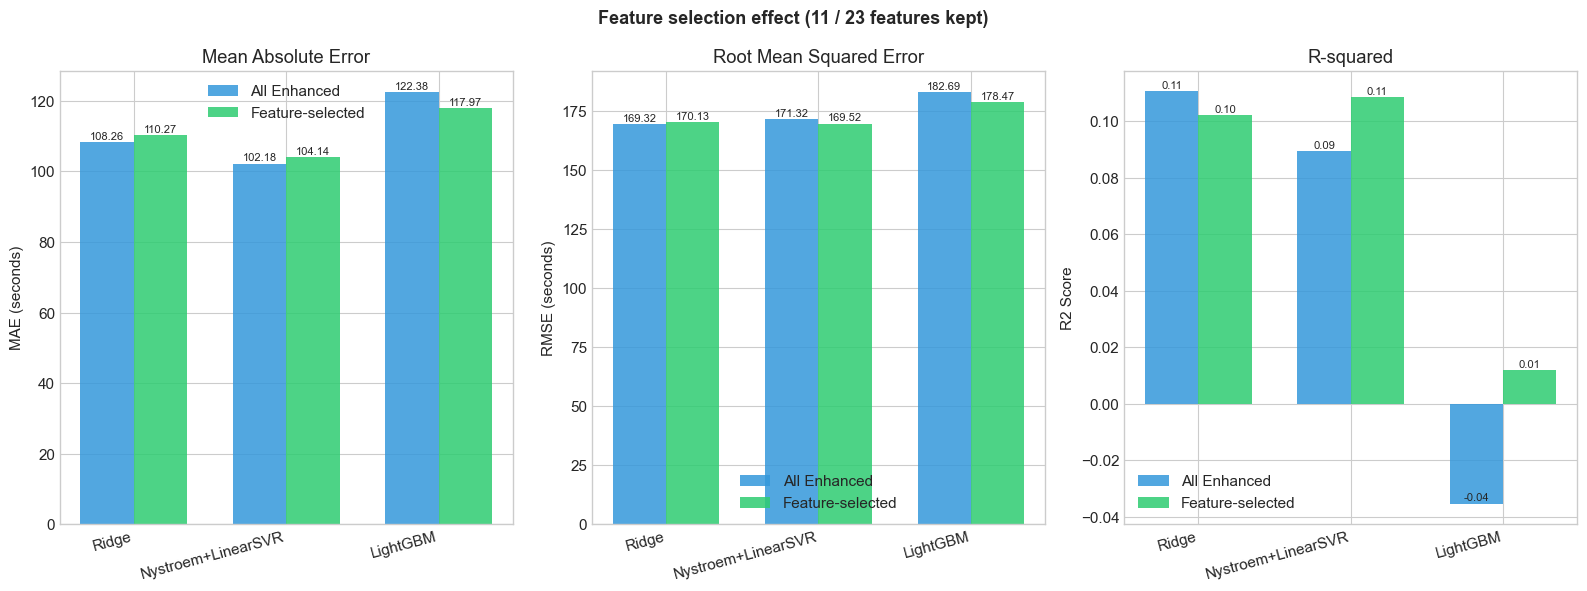

In [144]:
# ============================================================
# 9. Feature selection based on LightGBM gain importance
# ============================================================
print("=" * 60)
print("9. Feature selection (LightGBM gain >= 1% of total)")
print("=" * 60)

# --- Rank features by LightGBM Enhanced gain importance (from §5.1) ---
importance_full = importance_lgb_v2.copy()
total_gain = importance_full.sum()
importance_pct = (importance_full / total_gain * 100).round(3)

print("\nFeature importance ranking (% of total gain):")
print(importance_pct.to_string())

THRESHOLD_FRAC = 0.01
keep_mask = importance_full >= THRESHOLD_FRAC * total_gain
feature_cols_fs = list(importance_full[keep_mask].index)
dropped         = list(importance_full[~keep_mask].index)

print(f"\nThreshold: gain >= {THRESHOLD_FRAC*100:.0f}% of total")
print(f"  Kept ({len(feature_cols_fs)}): {feature_cols_fs}")
print(f"  Dropped ({len(dropped)}): {dropped}")

# --- Build reduced splits ---
X_train_fs = bus_enhanced[feature_cols_fs].iloc[:train_end]
X_val_fs   = bus_enhanced[feature_cols_fs].iloc[train_end:val_end]
X_test_fs  = bus_enhanced[feature_cols_fs].iloc[val_end:]
print(f"\nShapes: train={X_train_fs.shape}  val={X_val_fs.shape}  test={X_test_fs.shape}")

results_fs = {}

# ============================================================
# (1) Ridge (linear, L2) on reduced features
# ============================================================
print("\n--- Ridge (feature-selected) ---")
t0 = time.time()
if 'route_short_name' in feature_cols_fs:
    route_train_fs = ohe.transform(X_train_fs[['route_short_name']])
    route_val_fs   = ohe.transform(X_val_fs[['route_short_name']])
    route_test_fs  = ohe.transform(X_test_fs[['route_short_name']])
    num_cols_fs = [c for c in feature_cols_fs if c != 'route_short_name']
    X_train_lr_fs = np.hstack([X_train_fs[num_cols_fs].values, route_train_fs])
    X_val_lr_fs   = np.hstack([X_val_fs[num_cols_fs].values, route_val_fs])
    X_test_lr_fs  = np.hstack([X_test_fs[num_cols_fs].values, route_test_fs])
else:
    X_train_lr_fs = X_train_fs.values.astype(float)
    X_val_lr_fs   = X_val_fs.values.astype(float)
    X_test_lr_fs  = X_test_fs.values.astype(float)

ridge_fs = Ridge(alpha=1.0)
ridge_fs.fit(X_train_lr_fs, y_train)
y_pred = ridge_fs.predict(X_test_lr_fs)
mae, rmse, r2 = (mean_absolute_error(y_test, y_pred),
                  np.sqrt(mean_squared_error(y_test, y_pred)),
                  r2_score(y_test, y_pred))
results_fs['Ridge'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"   MAE: {mae:.2f}s | RMSE: {rmse:.2f}s | R2: {r2:.4f} | ({time.time()-t0:.1f}s)")

# ============================================================
# (2) Nystroem(RBF) + LinearSVR (best SVM) on reduced features
# ============================================================
print("\n--- Nystroem(RBF) + LinearSVR (feature-selected) ---")
t0 = time.time()
scaler_fs = StandardScaler()
X_train_svm_fs = scaler_fs.fit_transform(X_train_lr_fs)
X_test_svm_fs  = scaler_fs.transform(X_test_lr_fs)

ny_svr_fs = Pipeline([
    ('nystroem', Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42)),
    ('svr', LinearSVR(C=1.0, epsilon=0.0, max_iter=2000, random_state=42)),
])
ny_svr_fs.fit(X_train_svm_fs, y_train)
y_pred = ny_svr_fs.predict(X_test_svm_fs)
mae, rmse, r2 = (mean_absolute_error(y_test, y_pred),
                  np.sqrt(mean_squared_error(y_test, y_pred)),
                  r2_score(y_test, y_pred))
results_fs['Nystroem+LinearSVR'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"   MAE: {mae:.2f}s | RMSE: {rmse:.2f}s | R2: {r2:.4f} | ({time.time()-t0:.1f}s)")

# ============================================================
# (3) LightGBM on reduced features
# ============================================================
print("\n--- LightGBM (feature-selected) ---")
t0 = time.time()
X_train_lgb_fs = X_train_fs.copy()
X_val_lgb_fs   = X_val_fs.copy()
X_test_lgb_fs  = X_test_fs.copy()
if 'route_short_name' in feature_cols_fs:
    for df in (X_train_lgb_fs, X_val_lgb_fs, X_test_lgb_fs):
        df['route_short_name'] = df['route_short_name'].astype('category')

lgb_fs = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=63, max_depth=-1,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_fs.fit(
    X_train_lgb_fs, y_train,
    eval_set=[(X_val_lgb_fs, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)
y_pred = lgb_fs.predict(X_test_lgb_fs)
mae, rmse, r2 = (mean_absolute_error(y_test, y_pred),
                  np.sqrt(mean_squared_error(y_test, y_pred)),
                  r2_score(y_test, y_pred))
results_fs['LightGBM'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"   MAE: {mae:.2f}s | RMSE: {rmse:.2f}s | R2: {r2:.4f} | ({time.time()-t0:.1f}s)")

# ============================================================
# Comparison: Enhanced (all) vs Feature-selected
# ============================================================
print("\n" + "=" * 60)
print("Enhanced (all features) vs Feature-Selected")
print("=" * 60)

baseline = {
    'Ridge':              results_v2['Ridge Regression'],
    'Nystroem+LinearSVR': results_svm['Nystroem(RBF)+LinearSVR'],
    'LightGBM':           results_v2['LightGBM'],
}

rows = []
for m in ['Ridge', 'Nystroem+LinearSVR', 'LightGBM']:
    rows.append({'Model': m, 'Set': 'Enhanced (all)',
                 'MAE': baseline[m]['MAE'], 'RMSE': baseline[m]['RMSE'], 'R2': baseline[m]['R2']})
    rows.append({'Model': m, 'Set': 'Feature-selected',
                 'MAE': results_fs[m]['MAE'], 'RMSE': results_fs[m]['RMSE'], 'R2': results_fs[m]['R2']})
comparison_fs_df = pd.DataFrame(rows).set_index(['Model', 'Set'])
display(comparison_fs_df.round(3))

print("\nMAE delta (FS - Enhanced), negative = improvement:")
for m in ['Ridge', 'Nystroem+LinearSVR', 'LightGBM']:
    d = results_fs[m]['MAE'] - baseline[m]['MAE']
    print(f"  {m:<22s} {baseline[m]['MAE']:6.2f}s -> {results_fs[m]['MAE']:6.2f}s   {d:+.2f}s")

# --- Grouped bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
models = ['Ridge', 'Nystroem+LinearSVR', 'LightGBM']
x = np.arange(len(models))
width = 0.35

panels = [
    ('MAE',  'MAE (seconds)',  'Mean Absolute Error'),
    ('RMSE', 'RMSE (seconds)', 'Root Mean Squared Error'),
    ('R2',   'R2 Score',       'R-squared'),
]
for ax, (metric, ylabel, title) in zip(axes, panels):
    bvals = [baseline[m][metric]   for m in models]
    fvals = [results_fs[m][metric] for m in models]
    b1 = ax.bar(x - width/2, bvals, width, label='All Enhanced', color='#3498db', alpha=0.85)
    b2 = ax.bar(x + width/2, fvals, width, label='Feature-selected', color='#2ecc71', alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend()
    for rects in (b1, b2):
        for r in rects:
            h = r.get_height()
            ax.annotate(f'{h:.2f}', xy=(r.get_x()+r.get_width()/2, h),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', fontsize=8)

plt.suptitle(f'Feature selection effect ({len(feature_cols_fs)} / {len(enhanced_feature_cols)} features kept)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 10. Target transformation (Yeo-Johnson)

R² has plateaued around 0.11 across all model families, suggesting we're
hitting the information ceiling of the current features. The remaining lever
is on the **target side**: `delay_seconds` is almost certainly fat-tailed
(a handful of buses that are 10+ minutes late dominate the squared loss),
which hurts models that optimize L2 loss.

**Yeo-Johnson** is the right tool here — it handles negative values (early
arrivals) natively, unlike `log1p`. Procedure for each model:

1. Fit `PowerTransformer(method='yeo-johnson')` on `y_train` only (no leakage).
2. Train on the transformed target.
3. Predict, then `inverse_transform` back to seconds.
4. Report MAE/RMSE/R² **on the original seconds scale** for apples-to-apples.

Feature set is held fixed at **all Enhanced** so this is a clean A/B on the
target transformation alone.


10. Target transformation (Yeo-Johnson)
Raw delay_seconds stats (train only):
   min=-8315.0  max=9595.0  mean=50.1  median=6.0
   std=300.2  skewness=6.08  kurtosis=214.24
   99th pctile=1024.0  99.9th=2793.1

After Yeo-Johnson (lambda=0.9561):
   mean=0.000  std=1.000  skewness=-2.57  kurtosis=294.37


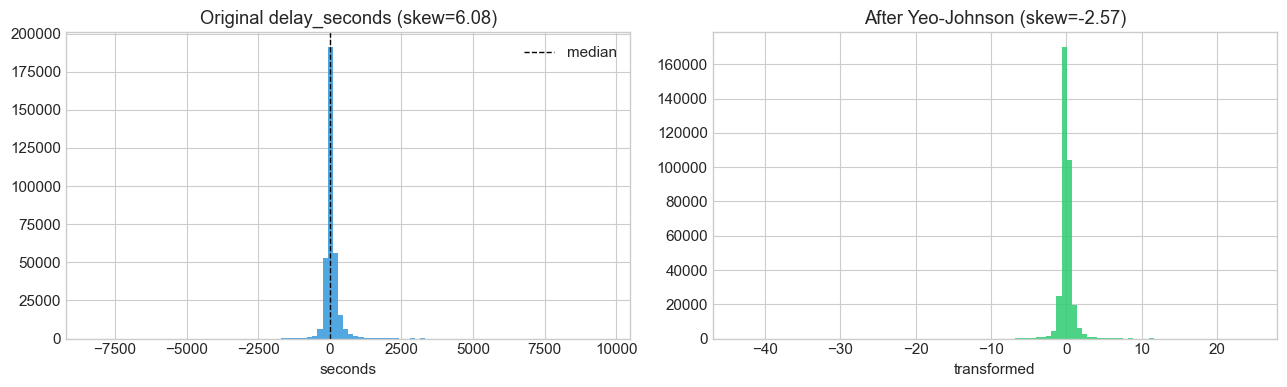


--- Ridge (target-transformed) ---
   MAE: 105.76s | RMSE: 169.23s | R2: 0.1116 | (0.2s)

--- Nystroem(RBF) + LinearSVR (target-transformed) ---
   MAE: 103.32s | RMSE: 171.70s | R2: 0.0854 | (17.5s)

--- LightGBM (target-transformed) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	valid_0's l1: 0.487135	valid_0's l2: 0.697238
   MAE: 113.25s | RMSE: 178.58s | R2: 0.0107 | (1.1s)

Untransformed vs Yeo-Johnson target (Enhanced features)


MAE     RMSE     R2
Model              Target                                
Ridge              untransformed  108.256  169.321  0.111
                   Yeo-Johnson    105.763  169.225  0.112
Nystroem+LinearSVR untransformed  102.177  171.325  0.089
                   Yeo-Johnson    103.319  171.704  0.085
LightGBM           untransformed  122.384  182.689 -0.035
                   Yeo-Johnson    113.253  178.576  0.011


Delta (Yeo-Johnson - untransformed), negative = improvement on MAE/RMSE:
  Ridge                  MAE -2.49s  RMSE -0.10s  R2 +0.0010
  Nystroem+LinearSVR     MAE +1.14s  RMSE +0.38s  R2 -0.0040
  LightGBM               MAE -9.13s  RMSE -4.11s  R2 +0.0461


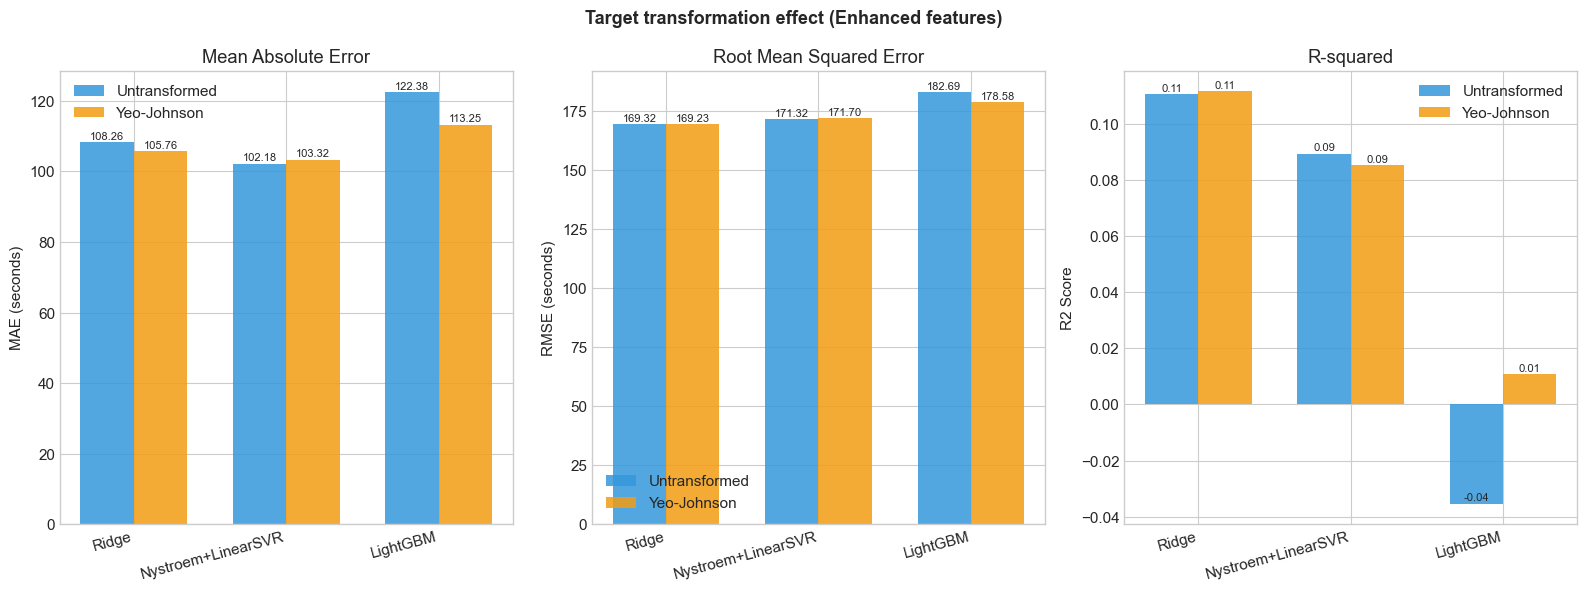

In [145]:
# ============================================================
# 10. Target transformation via Yeo-Johnson
# ============================================================
from sklearn.preprocessing import PowerTransformer

print("=" * 60)
print("10. Target transformation (Yeo-Johnson)")
print("=" * 60)

# --- Inspect raw target distribution ---
from scipy import stats as _stats
y_train_arr = np.asarray(y_train, dtype=float)
print(f"Raw delay_seconds stats (train only):")
print(f"   min={y_train_arr.min():.1f}  max={y_train_arr.max():.1f}  "
      f"mean={y_train_arr.mean():.1f}  median={np.median(y_train_arr):.1f}")
print(f"   std={y_train_arr.std():.1f}  skewness={_stats.skew(y_train_arr):.2f}  "
      f"kurtosis={_stats.kurtosis(y_train_arr):.2f}")
print(f"   99th pctile={np.percentile(y_train_arr, 99):.1f}  "
      f"99.9th={np.percentile(y_train_arr, 99.9):.1f}")

# --- Fit Yeo-Johnson on train only ---
pt = PowerTransformer(method='yeo-johnson', standardize=True)
y_train_t = pt.fit_transform(y_train_arr.reshape(-1, 1)).ravel()
y_val_t   = pt.transform(np.asarray(y_val, dtype=float).reshape(-1, 1)).ravel()
y_test_t  = pt.transform(np.asarray(y_test, dtype=float).reshape(-1, 1)).ravel()

print(f"\nAfter Yeo-Johnson (lambda={pt.lambdas_[0]:.4f}):")
print(f"   mean={y_train_t.mean():.3f}  std={y_train_t.std():.3f}  "
      f"skewness={_stats.skew(y_train_t):.2f}  kurtosis={_stats.kurtosis(y_train_t):.2f}")

# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y_train_arr, bins=100, color='#3498db', alpha=0.85)
axes[0].set_title(f'Original delay_seconds (skew={_stats.skew(y_train_arr):.2f})')
axes[0].set_xlabel('seconds')
axes[0].axvline(np.median(y_train_arr), color='k', ls='--', lw=1, label='median')
axes[0].legend()
axes[1].hist(y_train_t, bins=100, color='#2ecc71', alpha=0.85)
axes[1].set_title(f'After Yeo-Johnson (skew={_stats.skew(y_train_t):.2f})')
axes[1].set_xlabel('transformed')
plt.tight_layout()
plt.show()

results_tt = {}

# ============================================================
# (1) Ridge on transformed target, Enhanced features
# ============================================================
print("\n--- Ridge (target-transformed) ---")
t0 = time.time()
ridge_tt = Ridge(alpha=1.0)
ridge_tt.fit(X_train_lr_e, y_train_t)                        # existing Enhanced hstack
y_pred_t = ridge_tt.predict(X_test_lr_e)
y_pred   = pt.inverse_transform(y_pred_t.reshape(-1, 1)).ravel()
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
results_tt['Ridge'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"   MAE: {mae:.2f}s | RMSE: {rmse:.2f}s | R2: {r2:.4f} | ({time.time()-t0:.1f}s)")

# ============================================================
# (2) Nystroem(RBF) + LinearSVR on transformed target
# ============================================================
print("\n--- Nystroem(RBF) + LinearSVR (target-transformed) ---")
t0 = time.time()
ny_svr_tt = Pipeline([
    ('nystroem', Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42)),
    ('svr', LinearSVR(C=1.0, epsilon=0.0, max_iter=2000, random_state=42)),
])
ny_svr_tt.fit(X_train_svm, y_train_t)                        # scaled hstack from cell 29
y_pred_t = ny_svr_tt.predict(X_test_svm)
y_pred   = pt.inverse_transform(y_pred_t.reshape(-1, 1)).ravel()
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
results_tt['Nystroem+LinearSVR'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"   MAE: {mae:.2f}s | RMSE: {rmse:.2f}s | R2: {r2:.4f} | ({time.time()-t0:.1f}s)")

# ============================================================
# (3) LightGBM on transformed target
# ============================================================
print("\n--- LightGBM (target-transformed) ---")
t0 = time.time()
# Use the Enhanced features frame with categorical route
X_train_lgb_tt = X_train_e.copy()
X_val_lgb_tt   = X_val_e.copy()
X_test_lgb_tt  = X_test_e.copy()
for df in (X_train_lgb_tt, X_val_lgb_tt, X_test_lgb_tt):
    df['route_short_name'] = df['route_short_name'].astype('category')

lgb_tt = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=63, max_depth=-1,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_tt.fit(
    X_train_lgb_tt, y_train_t,
    eval_set=[(X_val_lgb_tt, y_val_t)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)
y_pred_t = lgb_tt.predict(X_test_lgb_tt)
y_pred   = pt.inverse_transform(y_pred_t.reshape(-1, 1)).ravel()
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
results_tt['LightGBM'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"   MAE: {mae:.2f}s | RMSE: {rmse:.2f}s | R2: {r2:.4f} | ({time.time()-t0:.1f}s)")

# ============================================================
# Comparison: untransformed vs Yeo-Johnson target
# ============================================================
print("\n" + "=" * 60)
print("Untransformed vs Yeo-Johnson target (Enhanced features)")
print("=" * 60)

baseline_tt = {
    'Ridge':              results_v2['Ridge Regression'],
    'Nystroem+LinearSVR': results_svm['Nystroem(RBF)+LinearSVR'],
    'LightGBM':           results_v2['LightGBM'],
}

rows = []
for m in ['Ridge', 'Nystroem+LinearSVR', 'LightGBM']:
    rows.append({'Model': m, 'Target': 'untransformed',
                 'MAE': baseline_tt[m]['MAE'], 'RMSE': baseline_tt[m]['RMSE'], 'R2': baseline_tt[m]['R2']})
    rows.append({'Model': m, 'Target': 'Yeo-Johnson',
                 'MAE': results_tt[m]['MAE'], 'RMSE': results_tt[m]['RMSE'], 'R2': results_tt[m]['R2']})
comparison_tt_df = pd.DataFrame(rows).set_index(['Model', 'Target'])
display(comparison_tt_df.round(3))

print("\nDelta (Yeo-Johnson - untransformed), negative = improvement on MAE/RMSE:")
for m in ['Ridge', 'Nystroem+LinearSVR', 'LightGBM']:
    d_mae  = results_tt[m]['MAE']  - baseline_tt[m]['MAE']
    d_rmse = results_tt[m]['RMSE'] - baseline_tt[m]['RMSE']
    d_r2   = results_tt[m]['R2']   - baseline_tt[m]['R2']
    print(f"  {m:<22s} MAE {d_mae:+.2f}s  RMSE {d_rmse:+.2f}s  R2 {d_r2:+.4f}")

# Grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
models = ['Ridge', 'Nystroem+LinearSVR', 'LightGBM']
x = np.arange(len(models))
width = 0.35
panels = [
    ('MAE',  'MAE (seconds)',  'Mean Absolute Error'),
    ('RMSE', 'RMSE (seconds)', 'Root Mean Squared Error'),
    ('R2',   'R2 Score',       'R-squared'),
]
for ax, (metric, ylabel, title) in zip(axes, panels):
    bvals = [baseline_tt[m][metric] for m in models]
    fvals = [results_tt[m][metric]  for m in models]
    b1 = ax.bar(x - width/2, bvals, width, label='Untransformed', color='#3498db', alpha=0.85)
    b2 = ax.bar(x + width/2, fvals, width, label='Yeo-Johnson',  color='#f39c12', alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend()
    for rects in (b1, b2):
        for r in rects:
            h = r.get_height()
            ax.annotate(f'{h:.2f}', xy=(r.get_x()+r.get_width()/2, h),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', fontsize=8)

plt.suptitle('Target transformation effect (Enhanced features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_target_transform.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 11. Progress summary & true baseline (plain OLS)

Before closing the notebook, two things:

1. **True baseline via plain `LinearRegression`** (no regularization) on both
   Base and Enhanced features. At n ≈ 1.7M the Ridge(α=1) regularization
   term is negligible (10⁻⁶ of the loss), so we expect essentially identical
   numbers to the Ridge baseline — but let's verify.
2. **One-shot progress table** aggregating every experiment in this notebook
   (Base / Enhanced / Enhance 2 / SVM variants / Feature-selected / Yeo-Johnson),
   sorted by MAE, with ΔMAE vs the true baseline.


11. Plain LinearRegression baseline

--- LinearRegression (Base features, no regularization) ---
   MAE: 118.26s | RMSE: 179.31s | R2: 0.0026
   (compare to Ridge Base:  MAE 118.25s, R2 0.0026)

--- LinearRegression (Enhanced features, no regularization) ---
   MAE: 108.26s | RMSE: 169.32s | R2: 0.1106
   (compare to Ridge Enhanced: MAE 108.26s, R2 0.1106)

Full progress summary

True baseline = LinearRegression (Base): MAE 118.26s, R2 0.0026

All experiments sorted by MAE (lower is better):



,Model,Set,MAE,RMSE,R2,dMAE vs baseline,MAE improvement %
0,Nystroem+LinearSVR,Enhanced,102.177,171.325,0.089,-16.083,13.60
1,Nystroem+LinearSVR,Enhanced + YeoJ,103.319,171.704,0.085,-14.940,12.63
2,Nystroem+LinearSVR,Enhanced + FS,104.143,169.524,0.108,-14.117,11.94
3,SVR(RBF) 20k subset,Enhanced,105.484,173.926,0.062,-12.776,10.80
4,Ridge,Enhanced + YeoJ,105.763,169.225,0.112,-12.497,10.57
5,LinearRegression,Enhanced,108.255,169.321,0.111,-10.004,8.46
6,Ridge,Enhanced,108.256,169.321,0.111,-10.004,8.46
7,Ridge,Enhanced + FS,110.266,170.125,0.102,-7.994,6.76
8,LightGBM,Enhanced + YeoJ,113.253,178.576,0.011,-5.007,4.23
9,Ridge,Enhance 2,117.307,184.077,-0.051,-0.953,0.81


CHAMPION: Nystroem+LinearSVR (Enhanced)
   MAE:  102.18s  (1.70 min)
   RMSE: 171.32s
   R2:   0.0894
   vs baseline (118.26s):
     MAE  -16.08s (13.6%)
     RMSE -7.98s (4.5%)
     R2   +0.0868


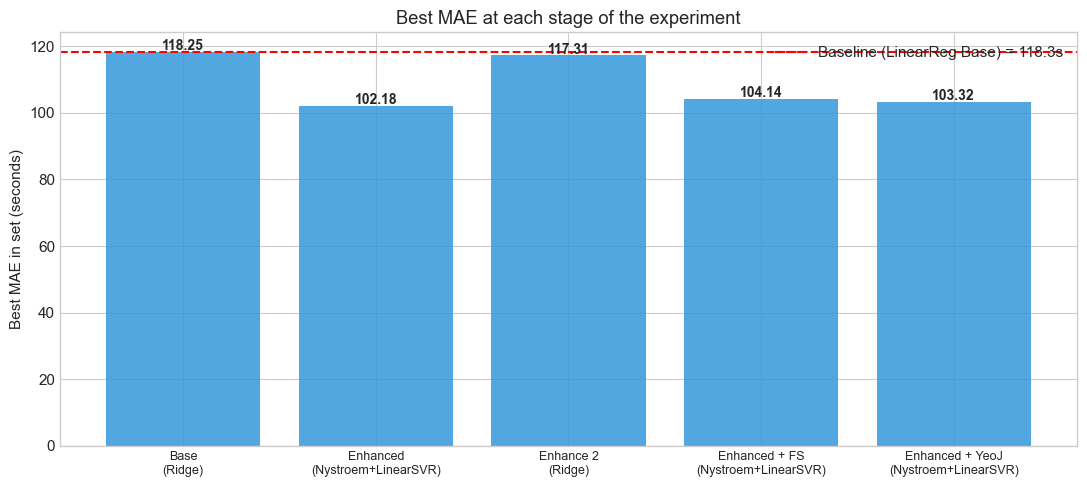

In [146]:
# ============================================================
# 11. True baseline (plain OLS) + full progress summary
# ============================================================
from sklearn.linear_model import LinearRegression

print("=" * 60)
print("11. Plain LinearRegression baseline")
print("=" * 60)

# --- (a) Plain LinearRegression on Base features ---
# Rebuild the Base design matrix from bus_enhanced[feature_cols] to avoid
# depending on any kernel state that may have been overwritten.
X_base_df = bus_enhanced[feature_cols]
X_train_base_df = X_base_df.iloc[:train_end]
X_test_base_df  = X_base_df.iloc[val_end:]

route_train_b = ohe.transform(X_train_base_df[['route_short_name']])
route_test_b  = ohe.transform(X_test_base_df[['route_short_name']])
numeric_cols_b = [c for c in feature_cols if c != 'route_short_name']
X_train_lr_b = np.hstack([X_train_base_df[numeric_cols_b].values.astype(float), route_train_b])
X_test_lr_b  = np.hstack([X_test_base_df[numeric_cols_b].values.astype(float),  route_test_b])

print("\n--- LinearRegression (Base features, no regularization) ---")
lr_base = LinearRegression()
lr_base.fit(X_train_lr_b, y_train)
y_pred = lr_base.predict(X_test_lr_b)
mae_lr_base  = mean_absolute_error(y_test, y_pred)
rmse_lr_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr_base   = r2_score(y_test, y_pred)
print(f"   MAE: {mae_lr_base:.2f}s | RMSE: {rmse_lr_base:.2f}s | R2: {r2_lr_base:.4f}")
print(f"   (compare to Ridge Base:  MAE {results['Ridge Regression']['MAE']:.2f}s, "
      f"R2 {results['Ridge Regression']['R2']:.4f})")

# --- (b) Plain LinearRegression on Enhanced features ---
print("\n--- LinearRegression (Enhanced features, no regularization) ---")
lr_enh = LinearRegression()
lr_enh.fit(X_train_lr_e, y_train)
y_pred = lr_enh.predict(X_test_lr_e)
mae_lr_enh  = mean_absolute_error(y_test, y_pred)
rmse_lr_enh = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr_enh   = r2_score(y_test, y_pred)
print(f"   MAE: {mae_lr_enh:.2f}s | RMSE: {rmse_lr_enh:.2f}s | R2: {r2_lr_enh:.4f}")
print(f"   (compare to Ridge Enhanced: MAE {results_v2['Ridge Regression']['MAE']:.2f}s, "
      f"R2 {results_v2['Ridge Regression']['R2']:.4f})")

# ============================================================
# Full progress table
# ============================================================
print("\n" + "=" * 60)
print("Full progress summary")
print("=" * 60)

progress_rows = [
    # (Model, Feature/Target set, MAE, RMSE, R2)
    ('LinearRegression',    'Base',        mae_lr_base,  rmse_lr_base,  r2_lr_base),
    ('Ridge',               'Base',        results['Ridge Regression']['MAE'], results['Ridge Regression']['RMSE'], results['Ridge Regression']['R2']),
    ('XGBoost',             'Base',        results['XGBoost']['MAE'], results['XGBoost']['RMSE'], results['XGBoost']['R2']),
    ('LightGBM',            'Base',        results['LightGBM']['MAE'], results['LightGBM']['RMSE'], results['LightGBM']['R2']),
    ('LinearRegression',    'Enhanced',    mae_lr_enh,   rmse_lr_enh,   r2_lr_enh),
    ('Ridge',               'Enhanced',    results_v2['Ridge Regression']['MAE'], results_v2['Ridge Regression']['RMSE'], results_v2['Ridge Regression']['R2']),
    ('XGBoost',             'Enhanced',    results_v2['XGBoost']['MAE'], results_v2['XGBoost']['RMSE'], results_v2['XGBoost']['R2']),
    ('LightGBM',            'Enhanced',    results_v2['LightGBM']['MAE'], results_v2['LightGBM']['RMSE'], results_v2['LightGBM']['R2']),
]

# Enhance 2 (may or may not exist in kernel)
if 'results_v3' in dir():
    for m in ('Ridge Regression', 'XGBoost', 'LightGBM'):
        r = results_v3[m]
        progress_rows.append((m.replace(' Regression', ''), 'Enhance 2', r['MAE'], r['RMSE'], r['R2']))

# SVM variants
if 'results_svm' in dir():
    progress_rows.append(('Nystroem+LinearSVR', 'Enhanced',
                          results_svm['Nystroem(RBF)+LinearSVR']['MAE'],
                          results_svm['Nystroem(RBF)+LinearSVR']['RMSE'],
                          results_svm['Nystroem(RBF)+LinearSVR']['R2']))
    progress_rows.append(('SVR(RBF) 20k subset', 'Enhanced',
                          results_svm['SVR(RBF) 20k subset']['MAE'],
                          results_svm['SVR(RBF) 20k subset']['RMSE'],
                          results_svm['SVR(RBF) 20k subset']['R2']))

# Feature selection
if 'results_fs' in dir():
    for m in ('Ridge', 'Nystroem+LinearSVR', 'LightGBM'):
        r = results_fs[m]
        progress_rows.append((m, 'Enhanced + FS', r['MAE'], r['RMSE'], r['R2']))

# Target transformation
if 'results_tt' in dir():
    for m in ('Ridge', 'Nystroem+LinearSVR', 'LightGBM'):
        r = results_tt[m]
        progress_rows.append((m, 'Enhanced + YeoJ', r['MAE'], r['RMSE'], r['R2']))

progress_df = pd.DataFrame(progress_rows, columns=['Model', 'Set', 'MAE', 'RMSE', 'R2'])

# Use plain OLS on Base as the true baseline
baseline_mae  = mae_lr_base
baseline_rmse = rmse_lr_base
baseline_r2   = r2_lr_base
progress_df['dMAE vs baseline']  = progress_df['MAE']  - baseline_mae
progress_df['MAE improvement %'] = ((baseline_mae - progress_df['MAE']) / baseline_mae * 100).round(2)

print(f"\nTrue baseline = LinearRegression (Base): MAE {baseline_mae:.2f}s, R2 {baseline_r2:.4f}")
print("\nAll experiments sorted by MAE (lower is better):\n")
display(progress_df.sort_values('MAE').reset_index(drop=True).round(3))

# Champion
champion_idx = progress_df['MAE'].idxmin()
ch = progress_df.loc[champion_idx]
print("=" * 60)
print(f"CHAMPION: {ch['Model']} ({ch['Set']})")
print("=" * 60)
print(f"   MAE:  {ch['MAE']:.2f}s  ({ch['MAE']/60:.2f} min)")
print(f"   RMSE: {ch['RMSE']:.2f}s")
print(f"   R2:   {ch['R2']:.4f}")
print(f"   vs baseline ({baseline_mae:.2f}s):")
print(f"     MAE  -{baseline_mae - ch['MAE']:.2f}s ({(baseline_mae - ch['MAE'])/baseline_mae*100:.1f}%)")
print(f"     RMSE -{baseline_rmse - ch['RMSE']:.2f}s ({(baseline_rmse - ch['RMSE'])/baseline_rmse*100:.1f}%)")
print(f"     R2   +{ch['R2'] - baseline_r2:.4f}")

# Quick visualization: progression of best MAE per set
best_per_set = progress_df.loc[progress_df.groupby('Set')['MAE'].idxmin()].copy()
# Preserve chronological order
set_order = ['Base', 'Enhanced', 'Enhance 2', 'Enhanced + FS', 'Enhanced + YeoJ']
best_per_set['order'] = best_per_set['Set'].map({s: i for i, s in enumerate(set_order)})
best_per_set = best_per_set.sort_values('order').drop(columns='order')

fig, ax = plt.subplots(figsize=(11, 5))
xs = np.arange(len(best_per_set))
ax.bar(xs, best_per_set['MAE'].values, color='#3498db', alpha=0.85)
ax.axhline(baseline_mae, color='red', ls='--', lw=1.5, label=f'Baseline (LinearReg Base) = {baseline_mae:.1f}s')
ax.set_xticks(xs)
ax.set_xticklabels([f"{row['Set']}\n({row['Model']})" for _, row in best_per_set.iterrows()],
                   rotation=0, fontsize=9)
ax.set_ylabel('Best MAE in set (seconds)')
ax.set_title('Best MAE at each stage of the experiment')
ax.legend()
for i, (_, row) in enumerate(best_per_set.iterrows()):
    ax.text(i, row['MAE'] + 0.5, f"{row['MAE']:.2f}", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('model_progress_summary.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 12. Presentation summary (slide-ready charts)

Three charts for the slide deck. A `BASELINE_MAE` variable at the top of the
cell controls the horizontal reference line on all charts — set it to any
value you want to use as the "baseline" in the talk.

- **Chart 1**: Base features — LinearRegression, Ridge, LightGBM, Naive SVR (RBF, 20k subset)
- **Chart 2**: Feature Enhancement 1 vs 2 — Ridge, LightGBM, Naive SVR (RBF, 20k subset)
- **Chart 3**: Ridge, LightGBM, Nystroem+LinearSVR — all on Enhanced features

Note: "Naive SVR" means `SVR(kernel='rbf')` trained on a 20,000-row stratified
subsample of the training data. True SVR at full scale (1.7M rows) is O(n²–n³)
and infeasible; the subsample is the honest small-data version of SVM.


12. Slide summary (BASELINE_MAE = 118.26s)

--- Naive SVR(rbf) on Base features (20k subsample) ---
   MAE 109.86s  RMSE 177.98s  R2 0.0173  (41.5s)

--- Naive SVR(rbf) on Enhanced (reused from cell 29) ---
   MAE 105.48s

--- Naive SVR(rbf) on Enhance 2 features (20k subsample) ---
   MAE 111.69s  RMSE 179.60s  R2 -0.0006  (67.0s)


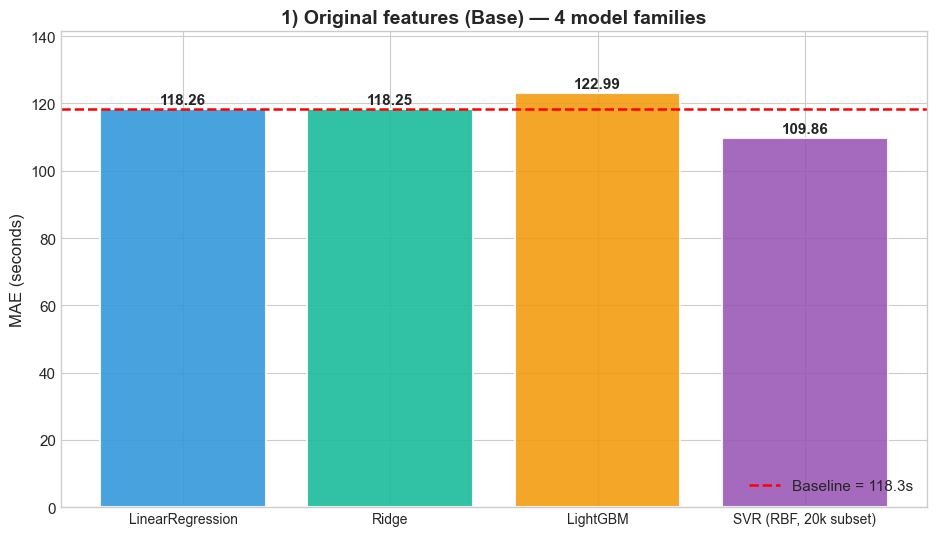

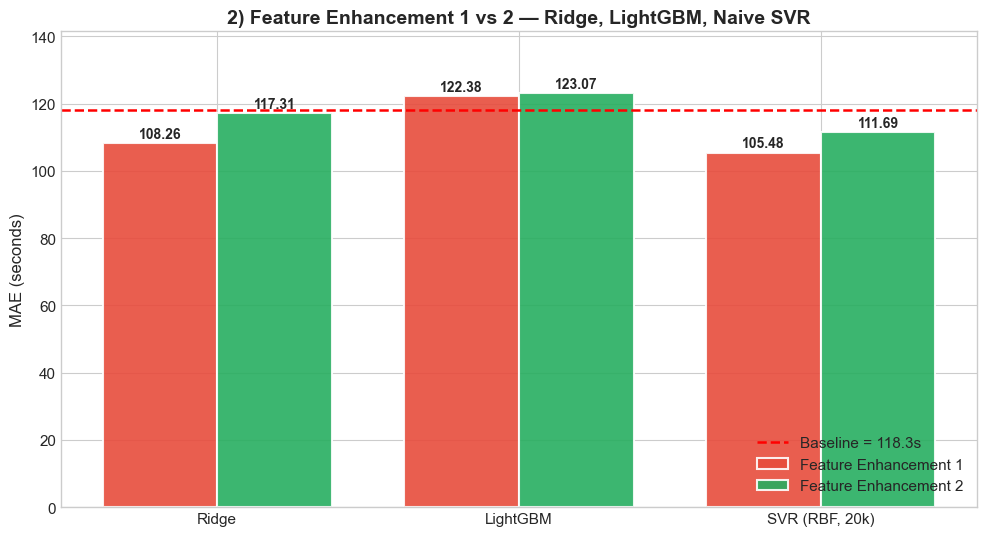

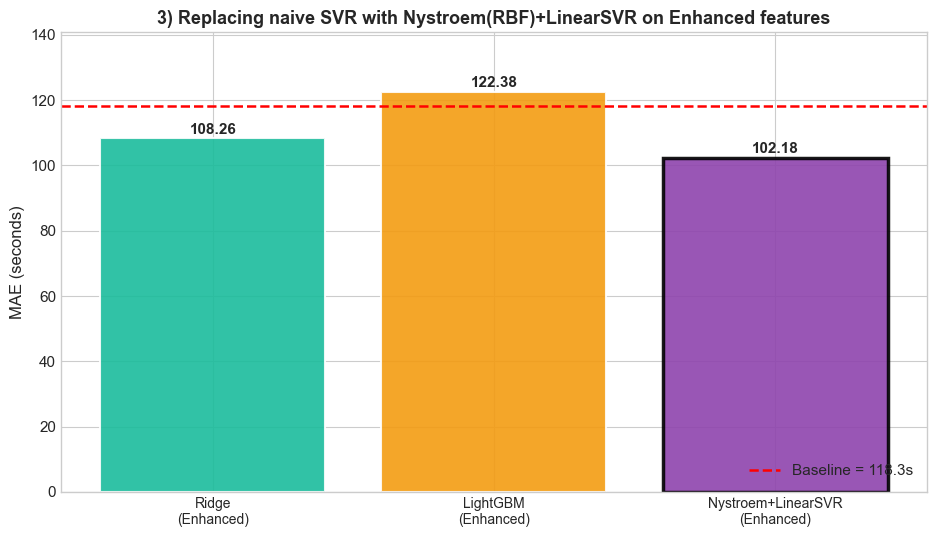


Slide-ready charts saved:
  slide_chart1_base.png         (Chart 1: Base)
  slide_chart2_enhancement.png  (Chart 2: Enhancement 1 & 2)
  slide_chart3_nystroem.png     (Chart 3: Nystroem SVR)

Champion (Chart 3): Nystroem+LinearSVR (Enhanced)
   MAE = 102.18s
   improvement vs baseline: 16.08s (13.6%)


In [148]:
# ============================================================
# 12. Presentation-ready summary charts
# ============================================================
# >>> TUNABLE: baseline MAE shown as red dashed line on all three charts.
#     Default is plain LinearRegression on Base features (from cell 37).
#     Replace with any numeric value you want to use as the talk baseline.
BASELINE_MAE = mae_lr_base  # e.g. BASELINE_MAE = 120.0
# ============================================================

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import time

print("=" * 60)
print(f"12. Slide summary (BASELINE_MAE = {BASELINE_MAE:.2f}s)")
print("=" * 60)

def fit_naive_svr(X_train_design, X_test_design, y_tr, y_te, subsample=20_000, seed=42):
    """Fit SVR(kernel='rbf') on a stratified subsample; evaluate on full test."""
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train_design)
    X_te_s = scaler.transform(X_test_design)
    rng = np.random.RandomState(seed)
    idx  = rng.choice(len(y_tr), size=min(subsample, len(y_tr)), replace=False)
    y_sub = y_tr.iloc[idx].values if hasattr(y_tr, 'iloc') else np.asarray(y_tr)[idx]
    svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale', cache_size=500)
    svr.fit(X_tr_s[idx], y_sub)
    y_pred = svr.predict(X_te_s)
    return (mean_absolute_error(y_te, y_pred),
            float(np.sqrt(mean_squared_error(y_te, y_pred))),
            r2_score(y_te, y_pred))

# ---- (a) Naive SVR on Base features (need to compute) ----
print("\n--- Naive SVR(rbf) on Base features (20k subsample) ---")
t0 = time.time()
svr_base_mae, svr_base_rmse, svr_base_r2 = fit_naive_svr(
    X_train_lr_b, X_test_lr_b, y_train, y_test,
)
print(f"   MAE {svr_base_mae:.2f}s  RMSE {svr_base_rmse:.2f}s  R2 {svr_base_r2:.4f}  ({time.time()-t0:.1f}s)")

# ---- (b) Naive SVR on Enhanced features (reuse cell 29 result) ----
svr_enh_mae = results_svm['SVR(RBF) 20k subset']['MAE']
print(f"\n--- Naive SVR(rbf) on Enhanced (reused from cell 29) ---")
print(f"   MAE {svr_enh_mae:.2f}s")

# ---- (c) Naive SVR on Enhance 2 features (need to compute) ----
print("\n--- Naive SVR(rbf) on Enhance 2 features (20k subsample) ---")
t0 = time.time()
_Xtr_v3 = bus_v3[feature_cols_v3].iloc[:train_end]
_Xte_v3 = bus_v3[feature_cols_v3].iloc[val_end:]
_rtr = ohe.transform(_Xtr_v3[['route_short_name']])
_rte = ohe.transform(_Xte_v3[['route_short_name']])
_nc  = [c for c in feature_cols_v3 if c != 'route_short_name']
X_train_lr_v3 = np.hstack([_Xtr_v3[_nc].values.astype(float), _rtr])
X_test_lr_v3  = np.hstack([_Xte_v3[_nc].values.astype(float), _rte])
svr_v3_mae, svr_v3_rmse, svr_v3_r2 = fit_naive_svr(
    X_train_lr_v3, X_test_lr_v3, y_train, y_test,
)
print(f"   MAE {svr_v3_mae:.2f}s  RMSE {svr_v3_rmse:.2f}s  R2 {svr_v3_r2:.4f}  ({time.time()-t0:.1f}s)")

# ============================================================
# Chart 1: Base features — LinReg, Ridge, LightGBM, Naive SVR
# ============================================================
chart1 = {
    'LinearRegression':      mae_lr_base,
    'Ridge':                 results['Ridge Regression']['MAE'],
    'LightGBM':              results['LightGBM']['MAE'],
    'SVR (RBF, 20k subset)': svr_base_mae,
}
fig1, ax1 = plt.subplots(figsize=(9.5, 5.5))
names = list(chart1.keys())
vals  = list(chart1.values())
colors = ['#3498db', '#1abc9c', '#f39c12', '#9b59b6']
bars = ax1.bar(names, vals, color=colors, alpha=0.9, edgecolor='white', linewidth=1.5)
ax1.axhline(BASELINE_MAE, color='red', ls='--', lw=1.8,
            label=f'Baseline = {BASELINE_MAE:.1f}s')
ax1.set_ylabel('MAE (seconds)', fontsize=12)
ax1.set_title('1) Original features (Base) — 4 model families',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.set_ylim(0, max(vals + [BASELINE_MAE]) * 1.15)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + 1.5, f'{v:.2f}',
             ha='center', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('slide_chart1_base.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Chart 2: Feature Enhancement 1 vs 2 — Ridge, LightGBM, Naive SVR
# ============================================================
models2 = ['Ridge', 'LightGBM', 'SVR (RBF, 20k)']
enh1_vals = [results_v2['Ridge Regression']['MAE'],
             results_v2['LightGBM']['MAE'],
             svr_enh_mae]
enh2_vals = [results_v3['Ridge Regression']['MAE'],
             results_v3['LightGBM']['MAE'],
             svr_v3_mae]
x = np.arange(len(models2))
width = 0.38

fig2, ax2 = plt.subplots(figsize=(10, 5.5))
b1 = ax2.bar(x - width/2, enh1_vals, width, label='Feature Enhancement 1',
             color='#e74c3c', alpha=0.9, edgecolor='white', linewidth=1.5)
b2 = ax2.bar(x + width/2, enh2_vals, width, label='Feature Enhancement 2',
             color='#27ae60', alpha=0.9, edgecolor='white', linewidth=1.5)
ax2.axhline(BASELINE_MAE, color='red', ls='--', lw=1.8,
            label=f'Baseline = {BASELINE_MAE:.1f}s')
ax2.set_ylabel('MAE (seconds)', fontsize=12)
ax2.set_title('2) Feature Enhancement 1 vs 2 — Ridge, LightGBM, Naive SVR',
              fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models2, fontsize=11)
ax2.legend(fontsize=11, loc='lower right')
ax2.set_ylim(0, max(enh1_vals + enh2_vals + [BASELINE_MAE]) * 1.15)
for rects in (b1, b2):
    for r in rects:
        h = r.get_height()
        ax2.text(r.get_x() + r.get_width() / 2, h + 1.5, f'{h:.2f}',
                 ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('slide_chart2_enhancement.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Chart 3: Ridge, LightGBM, Nystroem SVR — all on Enhanced
# ============================================================
chart3 = {
    'Ridge\n(Enhanced)':               results_v2['Ridge Regression']['MAE'],
    'LightGBM\n(Enhanced)':            results_v2['LightGBM']['MAE'],
    'Nystroem+LinearSVR\n(Enhanced)':  results_svm['Nystroem(RBF)+LinearSVR']['MAE'],
}
fig3, ax3 = plt.subplots(figsize=(9.5, 5.5))
names = list(chart3.keys())
vals  = list(chart3.values())
colors = ['#1abc9c', '#f39c12', '#8e44ad']
bars = ax3.bar(names, vals, color=colors, alpha=0.9, edgecolor='white', linewidth=1.5)
ax3.axhline(BASELINE_MAE, color='red', ls='--', lw=1.8,
            label=f'Baseline = {BASELINE_MAE:.1f}s')
# Highlight the champion
champ_idx = int(np.argmin(vals))
bars[champ_idx].set_edgecolor('black')
bars[champ_idx].set_linewidth(2.5)
ax3.set_ylabel('MAE (seconds)', fontsize=12)
ax3.set_title('3) Replacing naive SVR with Nystroem(RBF)+LinearSVR on Enhanced features',
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=11, loc='lower right')
ax3.set_ylim(0, max(vals + [BASELINE_MAE]) * 1.15)
for b, v in zip(bars, vals):
    ax3.text(b.get_x() + b.get_width() / 2, v + 1.5, f'{v:.2f}',
             ha='center', fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('slide_chart3_nystroem.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSlide-ready charts saved:")
print("  slide_chart1_base.png         (Chart 1: Base)")
print("  slide_chart2_enhancement.png  (Chart 2: Enhancement 1 & 2)")
print("  slide_chart3_nystroem.png     (Chart 3: Nystroem SVR)")

improvement = BASELINE_MAE - results_svm['Nystroem(RBF)+LinearSVR']['MAE']
print(f"\nChampion (Chart 3): Nystroem+LinearSVR (Enhanced)")
print(f"   MAE = {results_svm['Nystroem(RBF)+LinearSVR']['MAE']:.2f}s")
print(f"   improvement vs baseline: {improvement:.2f}s ({improvement/BASELINE_MAE*100:.1f}%)")
